In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import glob

from sklearn.cluster import DBSCAN
from scipy.cluster.vq import kmeans, vq, whiten


from astral import Observer
from astral.sun import sun
from zoneinfo import ZoneInfo
from functools import lru_cache




from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time


In [2]:
# Here are three types of DS:
# Flic button 
# Motion sensor
# Road surface

In [3]:
# Load and combine all three datasets
DS_FOLDER = "DS"

# FLIC BUTTON DATA 
flic_files = glob.glob(os.path.join(DS_FOLDER, 'flic_button_data_export_*.csv'))
flic_dfs = []
for file in flic_files:
    df = pd.read_csv(file)
    flic_dfs.append(df)
flic_df = pd.concat(flic_dfs)


# MOTION SENSOR DATA:
motion_files = glob.glob(os.path.join(DS_FOLDER, 'g_data_export_*.csv'))
motion_dfs = []
for file in motion_files:
    df = pd.read_csv(file)
    motion_dfs.append(df)
motion_df = pd.concat(motion_dfs)



# ROAD SURFACE DATA
road_files = glob.glob(os.path.join(DS_FOLDER, 'md30_export_*.csv'))
road_dfs = []
for file in road_files:
    df = pd.read_csv(file)
    road_dfs.append(df)
road_df = pd.concat(road_dfs)
print("Shape of FLic Button", flic_df.shape)
print("shape of motion", motion_df.shape)
print("Shape of road surface", road_df.shape)

Shape of FLic Button (890, 22)
shape of motion (26277, 22)
Shape of road surface (258260, 32)


<h3><center>Flic button DS<h3>


In [4]:
flic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 890 entries, 0 to 205
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               890 non-null    int64  
 1   ts               890 non-null    object 
 2   ruuvi            0 non-null      float64
 3   aplicom          890 non-null    object 
 4   companyid        0 non-null      float64
 5   address          890 non-null    object 
 6   rssi             890 non-null    int64  
 7   advdata          52 non-null     float64
 8   lat              890 non-null    float64
 9   lon              890 non-null    float64
 10  geom             890 non-null    object 
 11  temperature      0 non-null      float64
 12  accx             0 non-null      float64
 13  accy             0 non-null      float64
 14  accz             0 non-null      float64
 15  battvoltage      0 non-null      float64
 16  txpower          0 non-null      float64
 17  movcounter       0 no

In [5]:
# Drop all empty columns
flic_df = flic_df.dropna(axis=1, how='all')
flic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 890 entries, 0 to 205
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       890 non-null    int64  
 1   ts       890 non-null    object 
 2   aplicom  890 non-null    object 
 3   address  890 non-null    object 
 4   rssi     890 non-null    int64  
 5   advdata  52 non-null     float64
 6   lat      890 non-null    float64
 7   lon      890 non-null    float64
 8   geom     890 non-null    object 
dtypes: float64(3), int64(2), object(4)
memory usage: 69.5+ KB


**aplicom**: Receiving telematics gateway<br>
**address**: MAC address<br>
**rssi**:Signal strength in dBm<br>
**lat/lon**: GPS coordinates<br>
**geom**:PostGIS geometry

In [6]:
flic_df.head(10)

,id,ts,aplicom,address,rssi,advdata,lat,lon,geom
0,18615183,2025-11-10 01:50:40.22+02,Aplicom A11 001,80E4DA7EC61B,-60,NaN,60.493152,22.288016,0101000020E610000088B9A46ABB4936407FFACF9A1F3F...
1,18615186,2025-11-10 01:50:42.122+02,Aplicom A11 001,80E4DA7EC61B,-63,NaN,60.493151,22.288017,0101000020E610000029B16B7BBB493640AE7E6C921F3F...
2,18615187,2025-11-10 01:50:44.1+02,Aplicom A11 001,80E4DA7EC61B,-76,NaN,60.493150,22.288017,0101000020E610000029B16B7BBB493640DE02098A1F3F...
3,18615189,2025-11-10 01:50:45.963+02,Aplicom A11 001,80E4DA7EC61B,-55,NaN,60.493148,22.288014,0101000020E610000047CA1649BB4936403D0B42791F3F...
4,18615192,2025-11-10 01:50:48.722+02,Aplicom A11 001,80E4DA7EC61B,-54,NaN,60.493146,22.288012,0101000020E610000005DB8827BB4936409D137B681F3F...
5,18615194,2025-11-10 01:50:50.589+02,Aplicom A11 001,80E4DA7EC61B,-73,NaN,60.493145,22.288011,0101000020E610000065E3C116BB493640CC9717601F3F...
6,18615198,2025-11-10 01:50:52.461+02,Aplicom A11 001,80E4DA7EC61B,-61,NaN,60.493144,22.288011,0101000020E610000065E3C116BB493640FC1BB4571F3F...
7,18615200,2025-11-10 01:50:54.336+02,Aplicom A11 001,80E4DA7EC61B,-64,20106.0,60.493144,22.288011,0101000020E610000065E3C116BB493640FC1BB4571F3F...
8,18615201,2025-11-10 01:50:57.139+02,Aplicom A11 001,80E4DA7EC61B,-64,NaN,60.493143,22.288011,0101000020E610000065E3C116BB4936402CA0504F1F3F...
9,18615203,2025-11-10 01:50:58.983+02,Aplicom A11 001,80E4DA7EC61B,-69,NaN,60.493141,22.288015,0101000020E6100000E8C1DD59BB4936408BA8893E1F3F...


In [7]:
# Convert timestamp to datetime
flic_df['ts']=pd.to_datetime(flic_df['ts'],format='ISO8601',errors='coerce')
flic_df.head(50)

,id,ts,aplicom,address,rssi,advdata,lat,lon,geom
0,18615183,2025-11-10 01:50:40.220000+02:00,Aplicom A11 001,80E4DA7EC61B,-60,NaN,60.493152,22.288016,0101000020E610000088B9A46ABB4936407FFACF9A1F3F...
1,18615186,2025-11-10 01:50:42.122000+02:00,Aplicom A11 001,80E4DA7EC61B,-63,NaN,60.493151,22.288017,0101000020E610000029B16B7BBB493640AE7E6C921F3F...
2,18615187,2025-11-10 01:50:44.100000+02:00,Aplicom A11 001,80E4DA7EC61B,-76,NaN,60.493150,22.288017,0101000020E610000029B16B7BBB493640DE02098A1F3F...
3,18615189,2025-11-10 01:50:45.963000+02:00,Aplicom A11 001,80E4DA7EC61B,-55,NaN,60.493148,22.288014,0101000020E610000047CA1649BB4936403D0B42791F3F...
4,18615192,2025-11-10 01:50:48.722000+02:00,Aplicom A11 001,80E4DA7EC61B,-54,NaN,60.493146,22.288012,0101000020E610000005DB8827BB4936409D137B681F3F...
5,18615194,2025-11-10 01:50:50.589000+02:00,Aplicom A11 001,80E4DA7EC61B,-73,NaN,60.493145,22.288011,0101000020E610000065E3C116BB493640CC9717601F3F...
6,18615198,2025-11-10 01:50:52.461000+02:00,Aplicom A11 001,80E4DA7EC61B,-61,NaN,60.493144,22.288011,0101000020E610000065E3C116BB493640FC1BB4571F3F...
7,18615200,2025-11-10 01:50:54.336000+02:00,Aplicom A11 001,80E4DA7EC61B,-64,20106.0,60.493144,22.288011,0101000020E610000065E3C116BB493640FC1BB4571F3F...
8,18615201,2025-11-10 01:50:57.139000+02:00,Aplicom A11 001,80E4DA7EC61B,-64,NaN,60.493143,22.288011,0101000020E610000065E3C116BB4936402CA0504F1F3F...
9,18615203,2025-11-10 01:50:58.983000+02:00,Aplicom A11 001,80E4DA7EC61B,-69,NaN,60.493141,22.288015,0101000020E6100000E8C1DD59BB4936408BA8893E1F3F...


In [8]:
# Chekc the duplicate values in the dataset
print("Number of duplicate rows in flic_df:", flic_df.duplicated().sum())

Number of duplicate rows in flic_df: 0


In [9]:
flic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 890 entries, 0 to 205
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype                    
---  ------   --------------  -----                    
 0   id       890 non-null    int64                    
 1   ts       890 non-null    datetime64[ns, UTC+02:00]
 2   aplicom  890 non-null    object                   
 3   address  890 non-null    object                   
 4   rssi     890 non-null    int64                    
 5   advdata  52 non-null     float64                  
 6   lat      890 non-null    float64                  
 7   lon      890 non-null    float64                  
 8   geom     890 non-null    object                   
dtypes: datetime64[ns, UTC+02:00](1), float64(3), int64(2), object(3)
memory usage: 69.5+ KB


In [10]:
# The time range 
flic_df['ts'].min(), flic_df['ts'].max()

(Timestamp('2025-11-10 01:50:40.220000+0200', tz='UTC+02:00'),
 Timestamp('2026-01-09 22:30:19.288000+0200', tz='UTC+02:00'))

In [11]:
flic_df['aplicom'].unique()
# mmm, I have ds from one truck

array(['Aplicom A11 001'], dtype=object)

In [12]:
flic_df['address'].unique()

array(['80E4DA7EC61B'], dtype=object)

In [13]:
flic_df['advdata'].unique()
# I can not get 

array([   nan, 20106.])

In [14]:
flic_df["advdata"].dropna().astype(int).map(hex).value_counts()
# Only 52 rows and I have the same values, this is useless column 

advdata
0x4e8a    52
Name: count, dtype: int64

In [15]:
flic_df['advdata'].dropna().astype(int).map(hex).value_counts()

advdata
0x4e8a    52
Name: count, dtype: int64

In [16]:
flic_df[["lat","lon","geom"]].head(5)
#  geom the same location as lat/lon, just stored in a GIS binary format.
# Source: https://postgis.net/docs/using_postgis_dbmanagement.html

,lat,lon,geom
0,60.493152,22.288016,0101000020E610000088B9A46ABB4936407FFACF9A1F3F...
1,60.493151,22.288017,0101000020E610000029B16B7BBB493640AE7E6C921F3F...
2,60.493150,22.288017,0101000020E610000029B16B7BBB493640DE02098A1F3F...
3,60.493148,22.288014,0101000020E610000047CA1649BB4936403D0B42791F3F...
4,60.493146,22.288012,0101000020E610000005DB8827BB4936409D137B681F3F...


In [17]:
# where the Flic button was pressed
flic_df['location'] = flic_df['lat'].round(2).astype(str) + ', ' + flic_df['lon'].round(2).astype(str)
hotspots = flic_df['location'].value_counts().head(15)
print("TOP LOCATIONS:\n")
for i, (loc, count) in enumerate(hotspots.items(), 1):
    print(f" {i}. ({loc}): {count} presses")

TOP LOCATIONS:

 1. (60.49, 22.17): 42 presses
 2. (60.2, 23.11): 37 presses
 3. (60.24, 23.55): 34 presses
 4. (60.24, 23.58): 33 presses
 5. (60.38, 23.1): 32 presses
 6. (60.24, 23.56): 32 presses
 7. (60.24, 23.54): 31 presses
 8. (59.82, 22.96): 30 presses
 9. (60.42, 22.73): 30 presses
 10. (60.25, 23.52): 30 presses
 11. (60.39, 23.16): 27 presses
 12. (60.24, 23.57): 26 presses
 13. (60.22, 23.62): 23 presses
 14. (60.24, 23.53): 20 presses
 15. (60.39, 23.09): 19 presses


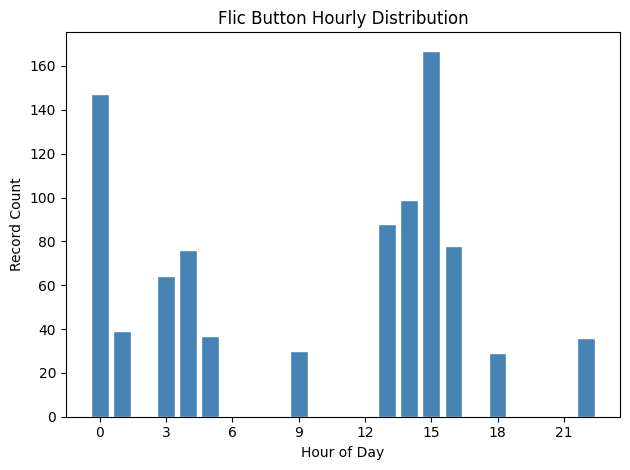

In [18]:
flic_hourly = flic_df['ts'].dt.hour.value_counts().sort_index()
plt.bar(flic_hourly.index, flic_hourly.values, color='steelblue', edgecolor='white')
plt.xlabel('Hour of Day')
plt.ylabel('Record Count')
plt.title('Flic Button Hourly Distribution')
plt.xticks(range(0, 24, 3))
plt.tight_layout()
plt.show()

In [19]:
peak_hour = flic_hourly.idxmax()
low_hour= flic_hourly.idxmin()
print(f"Peak hour: {peak_hour}:00 ({flic_hourly[peak_hour]}presses)")
print(f"Lowest hour: {low_hour}:00 ({flic_hourly[low_hour]}presses)")

Peak hour: 15:00 (167presses)
Lowest hour: 18:00 (29presses)


In [20]:
# Find the coverage area using lat and lon
lat_km =(flic_df['lat'].max()-flic_df['lat'].min())*111
lon_km = (flic_df['lon'].max()-flic_df['lon'].min())*55  
diagonal = np.sqrt(lat_km**2+lon_km**2)

print(f"Coverage is around: {diagonal:.0f} KM")

Coverage is around: 118 KM


In [21]:
# let's find the time difference between each row and the next one:
flic_df = flic_df.sort_values('ts')
time_diff = flic_df['ts'].diff().dt.total_seconds()
time_diff.describe()

count    8.890000e+02
mean     5.914937e+03
std      1.315977e+05
min      1.516000e+00
25%      1.531000e+00
50%      1.854000e+00
75%      1.973000e+00
max      3.665008e+06
Name: ts, dtype: float64

In [22]:
# The gaps are not one stable interval. What I can see, packets received between 1.5 seconds and 2 seconds.
# The max gap makes sense here because when the driver faced dangerous situation, the button was pressed.
# The data is not recorded continuously.

In [23]:
# One thing, it does not make sense to have so many presses 890 times and the gap time is small.
# I think something is wrong with the DS.
# So I should dive into details

In [24]:
# first thing I should do is sort by address and timestamp
# Then calculating time difference
# Based on threshold'cvalue, I can have session
threshold = pd.Timedelta("2min")

mac_time = flic_df.sort_values(["address","ts"])
gap_time = mac_time.groupby("address")["ts"].diff()
mac_time["session"]=(gap_time > threshold).groupby(mac_time["address"]).cumsum()

print("session",mac_time["session"].nunique())
print("session size stats:\n",mac_time.groupby(["address","session"]).size().describe())

session 17
session size stats:
 count     17.000000
mean      52.352941
std       50.344986
min        5.000000
25%       29.000000
50%       36.000000
75%       48.000000
max      202.000000
dtype: float64


In [25]:
# in easch session,  the min is 5 and the max presses is 202, which is not logical.
# 2 minutes threshold is not correct. I should consider  RSSI 

In [26]:
flic_df['rssi'].value_counts()

rssi
-61    63
-65    63
-60    61
-64    49
-66    49
-63    48
-69    45
-70    44
-67    44
-62    43
-68    41
-59    39
-58    28
-72    27
-57    26
-73    26
-71    24
-56    21
-75    20
-54    19
-74    17
-55    16
-76    13
-52    11
-77     8
-79     8
-80     7
-53     6
-78     5
-51     5
-81     3
-83     2
-82     2
-85     1
-89     1
-87     1
-84     1
-90     1
-86     1
-50     1
Name: count, dtype: int64

In [27]:
# the above output shows that the range of RSSI is between -50 and -90.
# most packets are in 58 and 76 dBm, few packets are between -85 and -90 dBm.
# If the button is located in stable position so why there are so many range of RSSI values?


#  When I googled: 
# BLE operates at the 2.4 GHz frequency. Water absorbs this frequency heavily, and the human body is mostly water.
# When a driver reaches out to press the button, their hand, arm, and winter clothing.
# This causing transient dips from -60 dBm down to -85 or -90 dBm during the exact moment of the press.

# Truck cabin is a metal cage: 
# When the Flic button broadcasts, the radio waves do not just travel in a straight line, 
# they bounce off the metal doors, dashboard, and windows. These reflected signals hit the receiver at slightly different times.
# Sometimes these waves combine to boost the signal (constructive interference, giving you -50 dBm), and sometimes they cancel each other out (destructive interference, dropping to -80 dBm).
# Even tiny movements from the driver or truck vibrations shift these reflection paths


# Flic button does not transmit on just one frequency. By standard design, it rapidly fires its burst of advertising packets across three completely different frequency Channels 37, 38, and 39.
# Because these channels are at different physical frequencies (2402 MHz, 2426 MHz, and 2480 MHz).

# Source: Theodore Rappaport, "Wireless Communications: Principles and Practice" - Multipath Propagation

In [28]:
# Based on my research on RSSI:
# This pattern is very consistent with BLE advertising being logged repeatedly, not one row = one physical press.
# Cource:https://academy.nordicsemi.com/courses/bluetooth-low-energy-fundamentals/lessons/lesson-2-bluetooth-le-advertising/topic/advertising-process

In [29]:
# I need to find the gap time distribution .
gap_time = (flic_df.sort_values(["address", "ts"]).groupby("address")["ts"].diff().dt.total_seconds().dropna())
quantiles = gap_time.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.97, 0.99])
print("Quantiles of gap time:\n", quantiles)
# 97 percent of the gap times are less than 4 second
# I am aiming to group the data based on the gap time.

Quantiles of gap time:
 0.25       1.53100
0.50       1.85400
0.75       1.97300
0.90       2.57000
0.95       3.05780
0.97       3.96944
0.99    4635.10912
Name: ts, dtype: float64


In [30]:
# 5 seconds is a good threshold to group the data into sessions. 
sorted_flic = flic_df.sort_values(["address", "ts"])
gap_second = sorted_flic.groupby("address")["ts"].diff().dt.total_seconds().dropna()
filtered_gaps = gap_second[gap_second < 6]

filtered_gaps.describe()

count    865.000000
mean       1.863698
std        0.442069
min        1.516000
25%        1.530000
50%        1.847000
75%        1.910000
max        4.758000
Name: ts, dtype: float64

In [31]:
gap_second.value_counts()
# I tried to find the BLE broadcast interval standard, 1.5 s is device's configured interval.
# But I have almost two broadcast intervals 1.5 and 1.8s
# 1.5 S is 382 packets, 1.8s is 256 packets.
# Is two broadcast intervals configured for the device? 


# Based on https://academy.nordicsemi.com/courses/bluetooth-low-energy-fundamentals/lessons/lesson-2-bluetooth-le-advertising/topic/advertising-process/ 
# Scan window: The time that a device spends scanning for packets at each scan interval.
# Both range from 2.5 ms to 10.24 seconds with a step increase of 0.625 ms  

ts
1.524       26
1.523       24
1.522       19
1.526       18
1.527       18
            ..
1.909        1
1.845        1
8124.923     1
1.841        1
2.803        1
Name: count, Length: 382, dtype: int64

In [32]:
# When I checked the ds.
# 1.5, 382 packets, median RSSI = -66.0
# 1.8, 242 packets, median RSSI = -62.5 
# 1.8 broadcast interval has stronger signal.   

<h2> <center> Clustering to find the real amount of press and real time of presses<h2>

In [33]:
"""
# Computing gap between each rows 
df= flic_df.sort_values(["address", "ts"]).copy()
df["gap_sec"] =df.groupby("address")["ts"].diff().dt.total_seconds()
gaps= df["gap_sec"].to_numpy()

# I used diff() function, the first row became nan. 
# I need to use filtering step and standard 
gaps =gaps[np.isfinite(gaps)&(gaps > 0)]
x= whiten(np.log(gaps)[:, None])

# Clustering big gap and small gap and labeling
# small gap is between each row inside of each packet
# the big gap is for detecting new press 
centroids, _ = kmeans(x, 2)
labels, _ = vq(x, centroids)
threshold = gaps[labels==np.argmin(centroids)].max()

# Creating press id and taking first row from each packet as real press time.
df["press_id"]=df["gap_sec"].gt(threshold).groupby(df["address"]).cumsum()
# Creating a new df, I am gonna use this as flic button press time.
presses_df=df.groupby(["address", "press_id"],as_index=False).first()[["address", "press_id", "ts", "rssi", "lat", "lon"]]


Sumamary = df.groupby("press_id")["ts"].agg(start_ts="first",packet_count="size",
    duration_sec=lambda seconds:(seconds.iloc[-1]-seconds.iloc[0]).total_seconds())


print("presses_df.shape:", presses_df.shape)
print(Sumamary)

# For bebugging, I used Qwen 3

"""

'\n# Computing gap between each rows \ndf= flic_df.sort_values(["address", "ts"]).copy()\ndf["gap_sec"] =df.groupby("address")["ts"].diff().dt.total_seconds()\ngaps= df["gap_sec"].to_numpy()\n\n# I used diff() function, the first row became nan. \n# I need to use filtering step and standard \ngaps =gaps[np.isfinite(gaps)&(gaps > 0)]\nx= whiten(np.log(gaps)[:, None])\n\n# Clustering big gap and small gap and labeling\n# small gap is between each row inside of each packet\n# the big gap is for detecting new press \ncentroids, _ = kmeans(x, 2)\nlabels, _ = vq(x, centroids)\nthreshold = gaps[labels==np.argmin(centroids)].max()\n\n# Creating press id and taking first row from each packet as real press time.\ndf["press_id"]=df["gap_sec"].gt(threshold).groupby(df["address"]).cumsum()\n# Creating a new df, I am gonna use this as flic button press time.\npresses_df=df.groupby(["address", "press_id"],as_index=False).first()[["address", "press_id", "ts", "rssi", "lat", "lon"]]\n\n\nSumamary = df.

In [34]:
"""# I can compare each packet with each other, to see the time and location difference between each press.
for pid in sorted(df["press_id"].dropna().astype(int).unique()):
    part= df.loc[df["press_id"]==pid,["press_id", "ts", "rssi", "lat", "lon"]].copy()
    part.insert(1, "row_idx", part.index)  
    print(f"\n=== press_id {pid} | rows={len(part)} ===")
    print(part.to_string(index=False))
# For better visibility of output, I used Qwen max.
"""

'# I can compare each packet with each other, to see the time and location difference between each press.\nfor pid in sorted(df["press_id"].dropna().astype(int).unique()):\n    part= df.loc[df["press_id"]==pid,["press_id", "ts", "rssi", "lat", "lon"]].copy()\n    part.insert(1, "row_idx", part.index)  \n    print(f"\n=== press_id {pid} | rows={len(part)} ===")\n    print(part.to_string(index=False))\n# For better visibility of output, I used Qwen max.\n'

In [35]:
# I can see that 12 presses or packages have same coordinates
# For first press, the coordinates are very close to each other.
# It seems, the car did not move fast, I checked the location, the car was on ISOPARTNER OY's yard in Turku.
# I think what if I use coordinates to find the speed between each press.

# I can do computing speed from sequential coordinate rows using Haversine
"""

df = df.sort_values(["press_id", "ts"])
R = 6371000 
rows = []
for p, g in df.groupby("press_id"):
    la = np.radians(g["lat"].to_numpy()); lo = np.radians(g["lon"].to_numpy())
    d = np.sum(2*R*np.arcsin(np.sqrt(np.sin((la[1:]-la[:-1])/2)**2 + np.cos(la[:-1])*np.cos(la[1:])*np.sin((lo[1:]-lo[:-1])/2)**2)))
    t = (g["ts"].iloc[-1]-g["ts"].iloc[0]).total_seconds() 
    rows.append([p, round(d, 1), round(t, 1), round(d/t*3.6, 2)])

print(pd.DataFrame(rows, columns=["Press_id", "Distance in meters", "Duration/second", "Average Speed/KMH"]))
"""

# I got the main code structure from here.
# Source: https://stackoverflow.com/questions/29545704/fast-haversine-approximation-python-pandas

'\n\ndf = df.sort_values(["press_id", "ts"])\nR = 6371000 \nrows = []\nfor p, g in df.groupby("press_id"):\n    la = np.radians(g["lat"].to_numpy()); lo = np.radians(g["lon"].to_numpy())\n    d = np.sum(2*R*np.arcsin(np.sqrt(np.sin((la[1:]-la[:-1])/2)**2 + np.cos(la[:-1])*np.cos(la[1:])*np.sin((lo[1:]-lo[:-1])/2)**2)))\n    t = (g["ts"].iloc[-1]-g["ts"].iloc[0]).total_seconds() \n    rows.append([p, round(d, 1), round(t, 1), round(d/t*3.6, 2)])\n\nprint(pd.DataFrame(rows, columns=["Press_id", "Distance in meters", "Duration/second", "Average Speed/KMH"]))\n'

In [36]:
# median press duration is 60 seconds and the max is 200 seconds around 3 minutes
# the press duration is quite long, I guess in some conditions, the driver had not pressed the button on time, the button was pressed lately.
# This is going to be issue to analyze dangerous situations based on motion ds and road surface ds. 
# One way is to detect the real time of dangerous situations based on motion df, to calculate the acceleration magnitude around the press time.

<h2><center> Grouping packets<h2>

In [37]:
# In previous cells, I found that 97 percent of the gap times are less than 4 second, I am gonna use 5 seconds as threshold to group the data into sessions.
# Threshold is in seconds!
threshold = 5.0

# I have one address, but I can use it still to group the DS into sessions based on time gap.
packets = flic_df.sort_values(["address", "ts"])
# Computing the time difference in seconds, between each packet and the previous packet
packets["gap_seconds"] = packets.groupby("address")["ts"].diff().dt.total_seconds()
# first packet has no previous packet, so gap_seconds is NaN
packets["Press_number"]=(packets["gap_seconds"].isna()|packets["gap_seconds"].gt(threshold)).groupby(packets["address"]).cumsum()

press_events =(packets.groupby(["address", "Press_number"],as_index=False).agg(
               start=("ts", "min"),end=("ts", "max"), packet_count=("ts", "size"),lat=("lat", "first"),lon=("lon", "first"),rssi_median=("rssi", "median")))

press_events["duration_s"] = (press_events["end"]-press_events["start"]).dt.total_seconds()
press_events

# The first row of each session can be the real press time. 

,address,Press_number,start,end,packet_count,lat,lon,rssi_median,duration_s
0,80E4DA7EC61B,1,2025-11-10 01:50:40.220000+02:00,2025-11-10 01:51:00.824000+02:00,11,60.493152,22.288016,-63.0,20.604
1,80E4DA7EC61B,2,2025-11-10 04:06:25.747000+02:00,2025-11-10 04:07:33.798000+02:00,39,60.383189,23.100664,-62.0,68.051
2,80E4DA7EC61B,3,2025-11-10 04:28:52.086000+02:00,2025-11-10 04:29:54.781000+02:00,37,60.204471,23.113718,-62.0,62.695
3,80E4DA7EC61B,4,2025-11-10 05:40:50.774000+02:00,2025-11-10 05:41:51.767000+02:00,37,60.009589,23.543561,-64.0,60.993
4,80E4DA7EC61B,5,2025-11-10 09:54:27.850000+02:00,2025-11-10 09:55:29.750000+02:00,30,59.819316,22.958070,-60.5,61.900
5,80E4DA7EC61B,6,2025-11-10 18:05:23.268000+02:00,2025-11-10 18:06:08.357000+02:00,27,60.386477,23.159415,-66.0,45.089
6,80E4DA7EC61B,7,2025-11-10 18:06:24.294000+02:00,2025-11-10 18:06:25.819000+02:00,2,60.384917,23.163049,-64.0,1.525
7,80E4DA7EC61B,8,2025-11-27 00:06:20.323000+02:00,2025-11-27 00:09:40.042000+02:00,122,60.234862,23.588156,-67.0,199.719
8,80E4DA7EC61B,9,2025-11-27 00:11:01.214000+02:00,2025-11-27 00:11:48.726000+02:00,25,60.248152,23.485509,-61.0,47.512
9,80E4DA7EC61B,10,2025-11-27 13:06:14.171000+02:00,2025-11-27 13:06:51.507000+02:00,20,60.482399,22.165015,-65.0,37.336


In [38]:
press_events['duration_s'].describe()

count     25.000000
mean      64.483960
std       43.632763
min        1.525000
25%       47.512000
50%       60.163000
75%       62.695000
max      199.719000
Name: duration_s, dtype: float64

In [39]:
# Printing each session with its summary information

for session in sorted(packets["Press_number"].unique()):
    # selecting only the packets that belong to the current press.
    part = packets.loc[packets["Press_number"] == session,["Press_number", "ts", "rssi", "lat", "lon"]]
    part.insert(1, "row_idx", part.index)
    summary = press_events.loc[press_events["Press_number"] == session].iloc[0]
    print(f"\nPress_number {session} | packets={len(part)} | duration={summary['duration_s']:.1f}s | rssi_median={summary['rssi_median']}:")
    print(part.to_string())
# For better visibility of output, I used Qwen max.


Press_number 1 | packets=11 | duration=20.6s | rssi_median=-63.0:
    Press_number  row_idx                               ts  rssi        lat        lon
0              1        0 2025-11-10 01:50:40.220000+02:00   -60  60.493152  22.288016
1              1        1 2025-11-10 01:50:42.122000+02:00   -63  60.493151  22.288017
2              1        2 2025-11-10 01:50:44.100000+02:00   -76  60.493150  22.288017
3              1        3 2025-11-10 01:50:45.963000+02:00   -55  60.493148  22.288014
4              1        4 2025-11-10 01:50:48.722000+02:00   -54  60.493146  22.288012
5              1        5 2025-11-10 01:50:50.589000+02:00   -73  60.493145  22.288011
6              1        6 2025-11-10 01:50:52.461000+02:00   -61  60.493144  22.288011
7              1        7 2025-11-10 01:50:54.336000+02:00   -64  60.493144  22.288011
8              1        8 2025-11-10 01:50:57.139000+02:00   -64  60.493143  22.288011
9              1        9 2025-11-10 01:50:58.983000+02:00   -6

In [40]:
daily = press_events["start"].dt.floor("D").value_counts().sort_index()
print(f"Max dangerous condition: {daily.max()} times. {daily.idxmax().date()}")

Max dangerous condition: 10 times. 2025-11-27


In [41]:
# https://stat.fi/en/publication/cm1630abg5qcv06w1yo8idxmh
# Based on the stat.fi in January the accidents rate was high.

In [42]:
# Let's figure out the dangerous condition by morning, afternoon, evening, night

def time_label(hour):
    if 6 <= hour < 12:
        return'Morning (06-12)' 
    elif 12 <=hour < 18:
        return 'Afternoon (12-18)'
    elif 18<= hour < 22:
        return 'Evening (18-22)'
    else:
        return'Night (22-06)'


press_events['hour']= press_events['start'].dt.hour
press_events['period'] =press_events['hour'].apply(time_label)
period_counts =press_events['period'].value_counts()
print("Dangerous Condition")

for period, count in period_counts.items():
    pertange =100*count/len(press_events)
    print(f"{period}: {count} events ({pertange}%)")

Dangerous Condition
Night (22-06): 11 events (44.0%)
Afternoon (12-18): 11 events (44.0%)
Evening (18-22): 2 events (8.0%)
Morning (06-12): 1 events (4.0%)


In [43]:
# Using geopy.geocoders.Nominatim to get the road names and town names:

geo = Nominatim(user_agent="hazard_analysis_turku_helsinki")
geocode_reverse = RateLimiter(geo.reverse, min_delay_seconds=1.1)
locations = []
for _, p in press_events.iterrows():
        loc = geocode_reverse(f"{p['lat']}, {p['lon']}", language="en", zoom=16)
        addr = loc.raw.get("address", {}) 
        road = addr.get("road",addr.get("hamlet", addr.get("suburb", "unknown")))
        town = addr.get("city",addr.get("town", addr.get("municipality", "")))
        locations.append({"press_idx": _, "road": road, "town": town, "full": loc.address})
  
loc_df=pd.DataFrame(locations)
press_events["road"]=loc_df["road"].values
press_events["town"]=loc_df["town"].values



print("ROAD NAMES AT PRESS EVENTS:\n")
for i, row in press_events.iterrows():
    print(f"Press {i+1:2d} {row['road']:30s} | {row['town']}")

print(f"\nMost dangerous roads:")
print(press_events.groupby("road").agg(presses=("Press_number","size")).sort_values("presses", ascending=False).head(10).to_string())

ROAD NAMES AT PRESS EVENTS:

Press  1 Telekatu                       | Turku
Press  2 Meriniitynkatu                 | Salon suuralue
Press  3 Haarlantie                     | Salo
Press  4 Ekerövägen                     | Raseborg
Press  5 Town Centre                    | Hanko
Press  6 Otsonkatu                      | Salon suuralue
Press  7 Ahmankatu                      | Salon suuralue
Press  8 Kiskontie                      | Salo
Press  9 Kiskontie                      | Salo
Press 10 Nesteentie                     | Raisio
Press 11 Nesteentie                     | Raisio
Press 12 Nesteentie                     | Raisio
Press 13 Turku-Helsinki moottoritie     | Salo
Press 14 Kiskontie                      | Salo
Press 15 Kiskontie                      | Salo
Press 16 Kiskontie                      | Salo
Press 17 Mustiontie                     | Lohja
Press 18 Nesteentie                     | Raisio
Press 19 Valtatie                       | Paimio
Press 20 Meriniityntie         

In [44]:
# For better understanding, I can use each press coordinates to find the day light 
# To see, if the darkness is one of the factors for dangerous situations.
# For better accurency, I am going to use each press coordinates.

# Use local Finland time. 
time_zone = ZoneInfo('Europe/Helsinki')

# for saving time.
@lru_cache(maxsize=None)
def sun_times(date, lat, lon):
    # creating object for astronomy calculation.
    observer= Observer(latitude=lat, longitude=lon)
    return sun(observer, date=date, tzinfo=time_zone)


# This function is going to check one row and returns true and false:
def is_dark_row(row):
    ts_local= row["start"].astimezone(time_zone)
    lat = round(float(row["lat"]),3)
    lon =round(float(row["lon"]),3)
    location_sun_time=sun_times(ts_local.date(),lat, lon)
    return ts_local<location_sun_time["dawn"]or ts_local>location_sun_time["dusk"]

press_events["is_dark"] = press_events.apply(is_dark_row, axis=1)
dark_count = int(press_events["is_dark"].sum())
print(f"Presses in DARKNESS: {dark_count}/{len(press_events)} ({dark_count/len(press_events)*100:.0f}%)")

for i, row in press_events.iterrows():

    ts_local =row["start"].astimezone(time_zone)
    lat = round(float(row["lat"]),3)
    lon= round(float(row["lon"]),3)
    s =sun_times(ts_local.date(),lat, lon)
    print(f"Press {i+1:2d} {ts_local:%Y-%m-%d %H:%M} | "
          f"dawn={s['dawn']:%H:%M} sunrise={s['sunrise']:%H:%M} "
          f"sunset={s['sunset']:%H:%M} dusk={s['dusk']:%H:%M} | "
          f"{'DARK' if row['is_dark'] else 'LIGHT'}")
    
# Source: https://astral.readthedocs.io/en/latest/
# For debugging, I used Qwen

Presses in DARKNESS: 13/25 (52%)
Press  1 2025-11-10 01:50 | dawn=07:30 sunrise=08:19 sunset=16:09 dusk=16:58 | DARK
Press  2 2025-11-10 04:06 | dawn=07:26 sunrise=08:15 sunset=16:06 dusk=16:55 | DARK
Press  3 2025-11-10 04:28 | dawn=07:25 sunrise=08:14 sunset=16:07 dusk=16:56 | DARK
Press  4 2025-11-10 05:40 | dawn=07:23 sunrise=08:11 sunset=16:06 dusk=16:55 | DARK
Press  5 2025-11-10 09:54 | dawn=07:24 sunrise=08:13 sunset=16:10 dusk=16:58 | LIGHT
Press  6 2025-11-10 18:05 | dawn=07:26 sunrise=08:15 sunset=16:06 dusk=16:55 | DARK
Press  7 2025-11-10 18:06 | dawn=07:26 sunrise=08:15 sunset=16:06 dusk=16:55 | DARK
Press  8 2025-11-27 00:06 | dawn=08:00 sunrise=08:54 sunset=15:31 dusk=16:25 | DARK
Press  9 2025-11-27 00:11 | dawn=08:00 sunrise=08:55 sunset=15:31 dusk=16:26 | DARK
Press 10 2025-11-27 13:06 | dawn=08:07 sunrise=09:02 sunset=15:35 dusk=16:30 | LIGHT
Press 11 2025-11-27 13:07 | dawn=08:07 sunrise=09:02 sunset=15:34 dusk=16:30 | LIGHT
Press 12 2025-11-27 13:08 | dawn=08:07 s

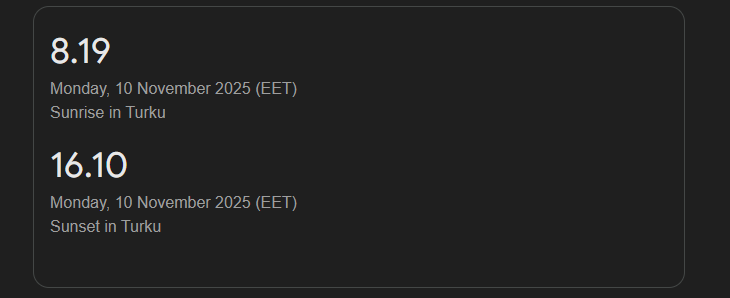

In [45]:
# First press is in Turku, I googled : 2025-11-10 sunrise and sunset in Turku.
# astronomy gave me the same time.

In [46]:
# save the press events to csv file
press_events.to_csv("press_events.csv", index=False)

<h3><center> Motion,  temperature and humidity DS<h3>

In [47]:
motion_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26277 entries, 0 to 4489
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               26277 non-null  int64  
 1   ts               26277 non-null  object 
 2   ruuvi            0 non-null      float64
 3   aplicom          26277 non-null  object 
 4   companyid        26277 non-null  int64  
 5   address          26277 non-null  object 
 6   rssi             26277 non-null  int64  
 7   advdata          26277 non-null  object 
 8   lat              26277 non-null  float64
 9   lon              26277 non-null  float64
 10  geom             26277 non-null  object 
 11  temperature      26277 non-null  float64
 12  accx             26277 non-null  int64  
 13  accy             26277 non-null  int64  
 14  accz             26277 non-null  int64  
 15  battvoltage      26277 non-null  float64
 16  txpower          26277 non-null  int64  
 17  movcounter       2

In [48]:
# here only one column is empty.
motion_df = motion_df.dropna(axis=1, how='all')
motion_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26277 entries, 0 to 4489
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               26277 non-null  int64  
 1   ts               26277 non-null  object 
 2   aplicom          26277 non-null  object 
 3   companyid        26277 non-null  int64  
 4   address          26277 non-null  object 
 5   rssi             26277 non-null  int64  
 6   advdata          26277 non-null  object 
 7   lat              26277 non-null  float64
 8   lon              26277 non-null  float64
 9   geom             26277 non-null  object 
 10  temperature      26277 non-null  float64
 11  accx             26277 non-null  int64  
 12  accy             26277 non-null  int64  
 13  accz             26277 non-null  int64  
 14  battvoltage      26277 non-null  float64
 15  txpower          26277 non-null  int64  
 16  movcounter       26277 non-null  int64  
 17  measseqnum       2

**accx, accy, accz**: Raw accelerometer readings<br>
**battvoltage**: Battery voltage<br>
**txpower**: Transmission power<br>
**movcounter**: Increments when motion detected

In [49]:
motion_df['ts'] = pd.to_datetime(motion_df['ts'], format='ISO8601',errors='coerce')
motion_df.head()

,id,ts,aplicom,companyid,address,rssi,advdata,lat,lon,geom,...,accx,accy,accz,battvoltage,txpower,movcounter,measseqnum,calibrated_accx,calibrated_accy,calibrated_accz
0,18615026,2025-11-10 01:48:05.187000+02:00,Aplicom A11 001,499,E78E9C0B06E0,-86,0201061bff9904050512ffffffff02a4fd0cfffc7e9655...,60.493215,22.287981,0101000020E61000008FDE701FB9493640C5724BAB213F...,...,676,-756,-4,2.612,4,85,7383,-36.640755,3.639896,2.106111
1,18615027,2025-11-10 01:48:07.150000+02:00,Aplicom A11 001,499,E78E9C0B06E0,-79,0201061bff9904050511ffffffff02a4fd14fff87e9655...,60.493212,22.287982,0101000020E610000030D63730B949364054FF2092213F...,...,676,-748,-8,2.612,4,85,7384,-41.093213,8.394061,8.235836
2,18615028,2025-11-10 01:48:09.034000+02:00,Aplicom A11 001,499,E198DBE2771E,-85,0201061bff9904050530ffffffff03dcfe8cfff074f668...,60.493206,22.287980,0101000020E6100000EFE6A90EB94936407218CC5F213F...,...,988,-372,-16,2.535,4,104,7184,-4.469715,42.277061,-1.047282
3,18615033,2025-11-10 01:48:20.720000+02:00,Aplicom A11 001,499,E78E9C0B06E0,-81,0201061bff9904050511ffffffff02a0fd0cfffc7e9655...,60.493177,22.288002,0101000020E6100000BE2EC37FBA493640D811876C203F...,...,672,-756,-4,2.612,4,85,7389,-36.175016,0.671586,4.746608
4,18615034,2025-11-10 01:48:23.017000+02:00,Aplicom A11 001,499,E198DBE2771E,-84,0201061bff9904050530ffffffff03dcfe94ffec74f668...,60.493175,22.288007,0101000020E6100000E204A6D3BA493640371AC05B203F...,...,988,-364,-20,2.535,4,104,7189,-6.271060,50.472670,2.049030


In [50]:
# Chekc the duplicate values in the dataset
print("Number of duplicate rows in flic_df:", motion_df.duplicated().sum())

Number of duplicate rows in flic_df: 0


In [51]:
# print the value account of address and aplican
motion_df['aplicom'].unique()

array(['Aplicom A11 001'], dtype=object)

In [52]:
print("Min temperature: ", motion_df['temperature'].min())
print("Max temperature", motion_df['temperature'].max())

# the max value for temperature is not possible.
# 326 is hotter than oven. 

Min temperature:  0.15
Max temperature 326.235


In [53]:
motion_df['temperature'].describe()

count    26277.000000
mean       211.198349
std        150.138414
min          0.150000
25%          7.680000
50%        316.445000
75%        323.440000
max        326.235000
Name: temperature, dtype: float64

In [54]:
# In the DF5 style encoding, temperature is a signed 16 bit number with 0.005 C steps. 
# If negative values were mistakenly interpreted as unsigned, they wrap near
# 65536*0.005 = 327.68 C
# So real -5.0 C can be about 327.68-5.0=322.68 C.
# 163.835 is the max valid
temp = motion_df["temperature"]
motion_df["temperature"]=temp.where(temp <= 163.835, temp-327.68)
print(motion_df["temperature"].agg(["min","max"]))

# Source: https://docs.ruuvi.com/communication/bluetooth-advertisements/data-format-5-rawv2
# https://stackoverflow.com/questions/79161913/how-to-calculate-temperature-right-from-ruuvitag-advertizement-packet

min   -16.360
max     9.455
Name: temperature, dtype: float64


In [55]:
motion_df['address'].unique()
# I have three motion sensors

array(['E78E9C0B06E0', 'E198DBE2771E', 'C3999872944C'], dtype=object)

In [56]:
motion_df["address"].value_counts()

address
E78E9C0B06E0    14657
E198DBE2771E     9851
C3999872944C     1769
Name: count, dtype: int64

In [57]:
for address in sorted(motion_df['address'].unique()):
    sensor= motion_df[motion_df['address'] ==address]
    print(f'{address}: {sensor["temperature"].min():.2f}-{sensor["temperature"].max():.2f} C'
          f'(median={sensor["temperature"].median():.2f})')

C3999872944C: -15.83-8.19 C(median=6.74)
E198DBE2771E: -15.47-9.46 C(median=-3.40)
E78E9C0B06E0: -16.36-8.45 C(median=-4.51)


In [58]:
# Let's analyze each sessor separately:
motion_df[motion_df["address"] == 'E78E9C0B06E0'].describe()

,id,companyid,rssi,lat,lon,temperature,accx,accy,accz,battvoltage,txpower,movcounter,measseqnum,calibrated_accx,calibrated_accy,calibrated_accz
count,1.465700e+04,14657.0,14657.00000,14657.000000,14657.000000,14657.000000,14657.000000,14657.000000,14657.000000,14657.000000,14657.0,14657.000000,14657.000000,14657.000000,14657.000000,14657.000000
mean,1.913631e+07,499.0,-87.17930,60.365457,22.932919,-2.580392,670.832776,-748.213413,6.749812,2.529742,4.0,159.768984,39029.426895,-25.856642,6.300932,11.023026
std,4.504126e+05,0.0,2.38929,0.125111,0.440156,6.946736,36.617475,38.092600,31.143688,0.089448,0.0,52.933734,21248.088201,30.810919,30.537532,43.358520
min,1.861503e+07,499.0,-95.00000,59.981633,22.097063,-16.360000,180.000000,-1264.000000,-352.000000,2.282000,4.0,0.000000,8.000000,-362.695711,-395.647829,-632.084685
25%,1.907459e+07,499.0,-89.00000,60.386163,22.722833,-4.795000,664.000000,-752.000000,0.000000,2.503000,4.0,132.000000,14830.000000,-35.093891,-0.591500,6.161160
50%,1.908368e+07,499.0,-87.00000,60.386185,23.106951,-4.510000,668.000000,-748.000000,12.000000,2.514000,4.0,186.000000,54149.000000,-20.091566,5.009054,11.662195
75%,1.909855e+07,499.0,-86.00000,60.426621,23.107008,2.820000,676.000000,-744.000000,20.000000,2.591000,4.0,186.000000,57109.000000,-12.870235,10.435351,15.764396
max,2.006978e+07,499.0,-67.00000,60.502904,23.852558,8.445000,1200.000000,-108.000000,656.000000,2.672000,4.0,254.000000,65470.000000,620.306215,357.732439,698.411454


In [59]:
motion_df[motion_df["address"] =='C3999872944C'].describe()
# This one was in warmner place than the other two.

,id,companyid,rssi,lat,lon,temperature,accx,accy,accz,battvoltage,txpower,movcounter,measseqnum,calibrated_accx,calibrated_accy,calibrated_accz
count,1.769000e+03,1769.0,1769.000000,1769.000000,1769.000000,1769.000000,1769.000000,1769.000000,1769.000000,1769.000000,1769.0,1769.000000,1769.000000,1769.000000,1769.000000,1769.000000
mean,1.902711e+07,499.0,-88.527417,60.377910,22.687977,0.851227,-355.491238,-1023.830413,-56.705483,2.446150,4.0,110.356699,24999.536461,-24.441605,-0.696080,-9.615089
std,6.286001e+05,0.0,2.100005,0.158448,0.660152,9.409127,45.394239,63.463947,89.977019,0.154448,0.0,77.969676,16966.534556,91.219464,36.414693,67.358392
min,1.861521e+07,499.0,-95.000000,59.982461,22.097105,-15.830000,-984.000000,-2040.000000,-1128.000000,2.046000,4.0,0.000000,3007.000000,-1115.062094,-264.745528,-1123.722275
25%,1.862467e+07,499.0,-90.000000,60.392984,22.097837,-12.365000,-364.000000,-1040.000000,-68.000000,2.246000,4.0,31.000000,12528.000000,-35.263904,-8.862137,-23.485559
50%,1.863760e+07,499.0,-88.000000,60.451961,22.099415,6.740000,-352.000000,-1024.000000,-60.000000,2.535000,4.0,116.000000,23174.000000,-27.987572,5.443287,-7.213740
75%,2.004643e+07,499.0,-87.000000,60.452439,23.543243,7.135000,-340.000000,-1008.000000,-52.000000,2.549000,4.0,177.000000,31505.000000,-20.105665,12.841506,-1.026285
max,2.006978e+07,499.0,-79.000000,60.502767,23.648956,8.190000,304.000000,-424.000000,1668.000000,2.570000,4.0,253.000000,65366.000000,1733.760877,439.917526,742.479811


In [60]:
# Let's analyze each sessor separately:
motion_df[motion_df["address"]=='E198DBE2771E'].describe()
# This one has high calibrated_accy and  calibrated_accz
# a lot shots

,id,companyid,rssi,lat,lon,temperature,accx,accy,accz,battvoltage,txpower,movcounter,measseqnum,calibrated_accx,calibrated_accy,calibrated_accz
count,9.851000e+03,9851.0,9851.000000,9851.000000,9851.000000,9851.000000,9851.000000,9851.000000,9851.000000,9851.000000,9851.000000,9851.000000,9851.000000,9851.000000,9851.000000,9851.000000
mean,1.914785e+07,499.0,-87.592021,60.328357,22.955280,-1.861440,988.452746,-361.266267,-9.987108,2.370271,3.999797,167.385748,40759.686123,4.096819,50.290977,2.689630
std,4.394988e+05,0.0,2.212960,0.167033,0.459132,6.738813,24.674278,172.182149,42.471293,0.110248,0.020151,55.420235,20796.616246,77.914798,145.349785,69.728382
min,1.861503e+07,499.0,-95.000000,59.819417,22.097018,-15.470000,476.000000,-1084.000000,-576.000000,2.004000,2.000000,0.000000,777.000000,-632.594218,-555.080147,-536.891317
25%,1.907570e+07,499.0,-89.000000,60.386157,23.106383,-3.625000,984.000000,-376.000000,-16.000000,2.320000,4.000000,167.000000,15425.000000,-5.601483,37.608987,-1.274952
50%,1.908376e+07,499.0,-88.000000,60.386179,23.106957,-3.400000,992.000000,-356.000000,-8.000000,2.363000,4.000000,193.000000,54176.000000,10.124630,55.726087,2.413302
75%,1.910053e+07,499.0,-86.000000,60.418850,23.107021,3.945000,996.000000,-344.000000,0.000000,2.426000,4.000000,193.000000,57077.000000,15.066472,65.631037,6.101555
max,2.006878e+07,499.0,-74.000000,60.502871,23.851690,9.455000,1596.000000,16494.000000,2825.000000,2.573000,4.000000,254.000000,65314.000000,7031.991503,14202.277312,6519.375053


In [61]:
# Analyzing  time gaps for each Sensor: 
for sensor, g in motion_df.groupby("address"):
    gaps = g["ts"].diff().dt.total_seconds().dropna()
    quantiles = gaps.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0])
    print(f"\n{sensor} records={len(g)}")
    print(quantiles.round(2))


C3999872944C records=1769
0.25          3.05
0.50          4.62
0.75          7.98
0.90         25.49
0.95        102.11
0.99       2329.25
1.00    3656145.45
Name: ts, dtype: float64

E198DBE2771E records=9851
0.25          1.55
0.50          3.06
0.75          4.92
0.90          8.49
0.95         15.64
0.99        322.57
1.00    3646985.76
Name: ts, dtype: float64

E78E9C0B06E0 records=14657
0.25          1.53
0.50          2.34
0.75          4.56
0.90          9.62
0.95         23.27
0.99        153.61
1.00    3652003.32
Name: ts, dtype: float64


In [62]:
# C3999872944C is the best receiver. other two sensors catch less packets.

In [63]:
# According my research, the advdata, measseqnum, movcounter. columns are meaningful.
# movcounter is 8 bit, it changes only when motion is detected, it counts how many motion events happened in  certain time
# measseqnum is 16 bit, helps me  see how reliable the connection was?
# advdata has 62 characters messages 

# Sources: https://academy.nordicsemi.com/courses/bluetooth-low-energy-fundamentals/lessons/lesson-2-bluetooth-le-advertising/topic/advertising-process/

In [64]:
# Let's take a look at advdata for each sensor 
for sensor, message in motion_df.groupby("address"):
    print(sensor, message["advdata"].astype(str).str.len().value_counts().to_dict())

# In E198 sensor, one row is corrupted, the length of advdata is 61.

C3999872944C {62: 1769}
E198DBE2771E {62: 9850, 60: 1}
E78E9C0B06E0 {62: 14657}


In [65]:
# I have to remove the corrupted row:
motion_df = motion_df[~((motion_df["address"] == "E198DBE2771E")&(motion_df["advdata"].astype(str).str.len() != 62))]
motion_df.shape

(26276, 21)

In [66]:
# Now  let's take a look at movcounter and  measseqnum for each sensor
for sensor, messag_count in motion_df.groupby("address"):
    print(sensor, messag_count["movcounter"].value_counts().to_dict())
print("\n")
for sensor, message_number in motion_df.sort_values(["address", "ts"]).groupby("address"):
    print(sensor, message_number["measseqnum"].diff().value_counts().to_dict())


C3999872944C {135: 266, 237: 191, 31: 110, 12: 101, 54: 82, 42: 67, 20: 63, 101: 56, 189: 56, 116: 53, 168: 50, 28: 45, 180: 36, 14: 29, 23: 26, 17: 21, 177: 21, 34: 16, 150: 14, 182: 14, 38: 14, 39: 13, 238: 12, 37: 12, 229: 11, 87: 11, 201: 10, 72: 10, 243: 10, 15: 9, 13: 8, 40: 8, 85: 8, 79: 6, 59: 6, 151: 6, 67: 6, 114: 5, 29: 5, 86: 5, 84: 5, 232: 5, 68: 5, 45: 5, 227: 5, 235: 4, 24: 4, 185: 4, 147: 4, 7: 4, 91: 4, 239: 4, 71: 4, 170: 4, 43: 4, 3: 3, 11: 3, 50: 3, 22: 3, 166: 3, 215: 3, 138: 3, 146: 3, 204: 3, 95: 3, 57: 3, 2: 3, 244: 3, 164: 3, 158: 3, 65: 3, 30: 3, 36: 3, 77: 3, 16: 2, 10: 2, 142: 2, 242: 2, 1: 2, 8: 2, 93: 2, 74: 2, 81: 2, 230: 2, 82: 2, 253: 2, 27: 2, 218: 2, 194: 2, 181: 2, 129: 2, 47: 2, 88: 2, 113: 2, 223: 2, 94: 2, 187: 2, 210: 2, 197: 2, 245: 2, 103: 2, 44: 2, 191: 2, 188: 2, 100: 2, 152: 2, 18: 2, 107: 2, 183: 2, 51: 2, 192: 2, 241: 2, 25: 2, 33: 2, 48: 2, 231: 2, 121: 2, 123: 2, 139: 2, 228: 2, 249: 1, 250: 1, 251: 1, 143: 1, 160: 1, 174: 1, 73: 1, 165:

In [ ]:
# 1 means good continuity
# 2 means gaps or missing packets
# So sensor C39 has more skips.
# https://docs.ruuvi.com/communication/bluetooth-advertisements/data-format-5-rawv


# Let's check the missing data
print("measseqnum step 16 bit:")
for sensor, messag_count in motion_df.groupby("address"):
    step= messag_count["measseqnum"].diff().mod(65536)
    print(sensor, step.dropna().value_counts().head(10).to_dict())

print("\nmovcounter step 8 bit:")
for sensor, messag_count in motion_df.groupby("address"):
    step = messag_count["movcounter"].diff().mod(256)
    print(sensor, step.dropna().value_counts().head(10).to_dict())
# measseqnum goes up 

measseqnum step 16 bit:
C3999872944C {2.0: 643, 1.0: 534, 3.0: 112, 0.0: 94, 4.0: 90, 5.0: 45, 7.0: 27, 9.0: 19, 6.0: 16, 10.0: 14}
E198DBE2771E {1.0: 4724, 2.0: 2466, 0.0: 1249, 3.0: 470, 4.0: 264, 5.0: 141, 7.0: 65, 6.0: 50, 9.0: 29, 8.0: 24}
E78E9C0B06E0 {1.0: 7454, 2.0: 2551, 0.0: 2507, 3.0: 555, 4.0: 366, 5.0: 184, 6.0: 112, 7.0: 92, 9.0: 79, 8.0: 55}

movcounter step 8 bit:
C3999872944C {0.0: 1449, 1.0: 43, 2.0: 27, 6.0: 17, 5.0: 17, 3.0: 17, 11.0: 13, 8.0: 13, 13.0: 12, 4.0: 12}
E198DBE2771E {0.0: 9248, 1.0: 139, 2.0: 53, 3.0: 37, 4.0: 28, 5.0: 26, 7.0: 17, 6.0: 11, 9.0: 8, 10.0: 8}
E78E9C0B06E0 {0.0: 13249, 1.0: 88, 3.0: 86, 5.0: 77, 4.0: 74, 2.0: 62, 6.0: 50, 8.0: 48, 7.0: 44, 9.0: 42}


In [68]:
# Actaully that is surprising me, C3999872944C recorded less packets, but recorded more motion events.
# It can be mounted in vibration place. 

In [69]:
# Analyzing the RSSI  for each sensor:
for sensor, message in motion_df.groupby("address"):
    print(f"\n{sensor} RSSI stats:")
    print(message["rssi"].describe().round(1))
# Flic button has stronger signal than motion sensors. 


C3999872944C RSSI stats:
count    1769.0
mean      -88.5
std         2.1
min       -95.0
25%       -90.0
50%       -88.0
75%       -87.0
max       -79.0
Name: rssi, dtype: float64

E198DBE2771E RSSI stats:
count    9850.0
mean      -87.6
std         2.2
min       -95.0
25%       -89.0
50%       -88.0
75%       -86.0
max       -74.0
Name: rssi, dtype: float64

E78E9C0B06E0 RSSI stats:
count    14657.0
mean       -87.2
std          2.4
min        -95.0
25%        -89.0
50%        -87.0
75%        -86.0
max        -67.0
Name: rssi, dtype: float64


In [70]:
# top 1% of movements can be anomaly
anomaly_quantile = 0.998
# Gap for new motion anomaly for same sensor.
sensor_gap_time = 10
merge_gap = 10

df = motion_df.copy()
df["ts"] = pd.to_datetime(df["ts"])
df = df.sort_values(["address", "ts"]).reset_index(drop=True)

# Computing how much each sensor moved, combining  X, Y, Z axes into one number, which is total shake magnitude
df["acc_mag"] = np.sqrt(df["calibrated_accx"]**2 + df["calibrated_accy"]**2 + df["calibrated_accz"]**2)
df["acc_base"]= df.groupby("address")["acc_mag"].transform("median")
# How far is this reading from the sensor's calm baseline?
df["acc_dev"] = (df["acc_mag"]-df["acc_base"]).abs()
df["threshold"]= df.groupby("address")["acc_dev"].transform(lambda s: s.quantile(anomaly_quantile))
df["is_anomaly"]= df["acc_dev"] > df["threshold"]


anomalies = df[df["is_anomaly"]].copy()
# if two anomaly rows are close together less 10s, they belong to the same shake magnitude
anomalies["is_new_event"] = anomalies.groupby("address")["ts"].diff().gt(pd.Timedelta(seconds=sensor_gap_time)).fillna(True)
anomalies["sensor_event_id"] = anomalies.groupby("address")["is_new_event"].cumsum()


sensor_events = anomalies.groupby(["address", "sensor_event_id"], as_index=False).agg(start_ts = ("ts","min"), end_ts = ("ts","max"),
    n_packets = ("ts","size"),peak_mag = ("acc_mag","max"),lat =("lat","first"), lon=("lon","first"),).sort_values("start_ts", ignore_index=True)

# Merging overlapping events from different sensors
event_id = 1
event_ids = [1]
prev_end = sensor_events.loc[0, "end_ts"]

for _, row in sensor_events.iloc[1:].iterrows():
    gap_too_big = row["start_ts"]>prev_end + pd.Timedelta(seconds=merge_gap)
    if gap_too_big:
        event_id += 1
        prev_end = row["end_ts"]
    else:
        prev_end= max(prev_end, row["end_ts"])
    event_ids.append(event_id)

sensor_events["event_id"]=event_ids

motion_anomalies = sensor_events.groupby("event_id", as_index=False).agg(start_ts =("start_ts", "min"), end_ts= ("end_ts","max"),
    number_sensors = ("address", "nunique"), sensors = ("address", lambda s: sorted(set(s))),
    peak_mag = ("peak_mag", "max"), lat = ("lat","median"),lon= ("lon","median"),)
motion_anomalies["duration_s"] =(motion_anomalies["end_ts"] - motion_anomalies["start_ts"]).dt.total_seconds()

temp_per_event = anomalies.merge(sensor_events[["address", "sensor_event_id", "event_id"]], on=["address", "sensor_event_id"])
motion_anomalies["temperature"] = temp_per_event.groupby("event_id")["temperature"].median().values
motion_anomalies


# I got the anomaly detection and Grouping algorithm main code structure from Qwen Max3. 
# C3999872944C has strongest shakes, 10 th of November, 04:07:30

,event_id,start_ts,end_ts,number_sensors,sensors,peak_mag,lat,lon,duration_s,temperature
0,1,2025-11-10 02:04:14.754000+02:00,2025-11-10 02:04:14.754000+02:00,1,[E78E9C0B06E0],419.371971,60.485152,22.167961,0.000,6.6700
1,2,2025-11-10 03:14:10.806000+02:00,2025-11-10 03:14:10.806000+02:00,1,[E78E9C0B06E0],646.150462,60.472966,22.356873,0.000,7.6250
2,3,2025-11-10 03:35:31.169000+02:00,2025-11-10 03:35:31.169000+02:00,1,[E78E9C0B06E0],553.837363,60.425709,22.804997,0.000,7.6950
3,4,2025-11-10 03:39:14.273000+02:00,2025-11-10 03:39:14.273000+02:00,1,[E78E9C0B06E0],505.073284,60.428424,22.887160,0.000,7.6500
4,5,2025-11-10 03:42:07.700000+02:00,2025-11-10 03:42:07.700000+02:00,1,[E78E9C0B06E0],604.331398,60.435019,22.947340,0.000,7.7100
5,6,2025-11-10 03:59:06.742000+02:00,2025-11-10 03:59:08.261000+02:00,1,[E78E9C0B06E0],409.148308,60.391337,23.078367,1.519,7.8200
6,7,2025-11-10 03:59:31.809000+02:00,2025-11-10 03:59:31.809000+02:00,1,[E198DBE2771E],427.716645,60.391685,23.083194,0.000,8.5000
7,8,2025-11-10 04:06:32.817000+02:00,2025-11-10 04:06:32.817000+02:00,1,[C3999872944C],1317.101104,60.382527,23.101324,0.000,8.0150
8,9,2025-11-10 04:07:30.725000+02:00,2025-11-10 04:07:30.725000+02:00,1,[C3999872944C],2082.971129,60.376544,23.109678,0.000,8.0650
9,10,2025-11-10 04:17:06.868000+02:00,2025-11-10 04:17:06.868000+02:00,1,[E78E9C0B06E0],721.131432,60.323977,23.099130,0.000,8.0850


In [71]:
motion_anomalies['peak_mag'].describe()

count      45.000000
mean      635.107954
std       337.659264
min       388.628100
25%       442.837936
50%       527.748540
75%       637.197313
max      2082.971129
Name: peak_mag, dtype: float64

In [72]:
# Minimum peak magnitude is 388 g, which is strong shake

In [73]:
@lru_cache(maxsize=None)
def sun_times(date, lat, lon):
    # creating object for astronomy calculation.
    observer= Observer(latitude=lat, longitude=lon)
    return sun(observer, date=date, tzinfo=time_zone)


# This function is going to check one row and returns true and false:
def is_dark_row(row):
    ts_local= row["start_ts"].astimezone(time_zone)
    lat = round(float(row["lat"]),3)
    lon =round(float(row["lon"]),3)
    location_sun_time=sun_times(ts_local.date(),lat, lon)
    return ts_local<location_sun_time["dawn"]or ts_local>location_sun_time["dusk"]

motion_anomalies["is_dark"] = motion_anomalies.apply(is_dark_row, axis=1)
dark_count = int(motion_anomalies["is_dark"].sum())
print(f"Motion anomaly in DARKNESS: {dark_count} / {len(motion_anomalies)} ({dark_count/len(motion_anomalies)*100:.0f}%)")

for i, row in motion_anomalies.iterrows():

    ts_local =row["start_ts"].astimezone(time_zone)
    lat = round(float(row["lat"]),3)
    lon= round(float(row["lon"]),3)
    s =sun_times(ts_local.date(),lat, lon)
    print(f"Anomaly {i+1:2d} {ts_local:%Y-%m-%d %H:%M} | "
          f"dawn={s['dawn']:%H:%M} sunrise={s['sunrise']:%H:%M} "
          f"sunset={s['sunset']:%H:%M} dusk={s['dusk']:%H:%M} | "
          f"{'DARK' if row['is_dark'] else 'LIGHT'}")

Motion anomaly in DARKNESS: 29 / 45 (64%)
Anomaly  1 2025-11-10 02:04 | dawn=07:30 sunrise=08:20 sunset=16:09 dusk=16:58 | DARK
Anomaly  2 2025-11-10 03:14 | dawn=07:29 sunrise=08:19 sunset=16:08 dusk=16:58 | DARK
Anomaly  3 2025-11-10 03:35 | dawn=07:27 sunrise=08:17 sunset=16:07 dusk=16:56 | DARK
Anomaly  4 2025-11-10 03:39 | dawn=07:27 sunrise=08:16 sunset=16:06 dusk=16:56 | DARK
Anomaly  5 2025-11-10 03:42 | dawn=07:27 sunrise=08:16 sunset=16:06 dusk=16:56 | DARK
Anomaly  6 2025-11-10 03:59 | dawn=07:26 sunrise=08:15 sunset=16:06 dusk=16:55 | DARK
Anomaly  7 2025-11-10 03:59 | dawn=07:26 sunrise=08:15 sunset=16:06 dusk=16:55 | DARK
Anomaly  8 2025-11-10 04:06 | dawn=07:26 sunrise=08:15 sunset=16:06 dusk=16:55 | DARK
Anomaly  9 2025-11-10 04:07 | dawn=07:26 sunrise=08:15 sunset=16:06 dusk=16:55 | DARK
Anomaly 10 2025-11-10 04:17 | dawn=07:26 sunrise=08:15 sunset=16:06 dusk=16:55 | DARK
Anomaly 11 2025-11-10 05:28 | dawn=07:23 sunrise=08:12 sunset=16:07 dusk=16:55 | DARK
Anomaly 12 2

In [74]:
daily = motion_anomalies["start_ts"].dt.floor("D").value_counts().sort_index()
print(f"Dangerous day: {daily.max()} times. {daily.idxmax().date()}")

Dangerous day: 30 times. 2025-11-10


In [75]:

geo = Nominatim(user_agent="hazard_analysis_turku_helsinki")
geocode_reverse = RateLimiter(geo.reverse, min_delay_seconds=1.1)
locations = []
for _, p in motion_anomalies.iterrows():
        loc = geocode_reverse(f"{p['lat']}, {p['lon']}", language="en", zoom=16)
        addr = loc.raw.get("address", {}) 
        road = addr.get("road", addr.get("hamlet", addr.get("suburb", "unknown")))
        town = addr.get("city", addr.get("town", addr.get("municipality", "")))
        locations.append({"press_idx": _, "road": road, "town": town, "full": loc.address})
  
loc_df=pd.DataFrame(locations)
motion_anomalies["road"]=loc_df["road"].values
motion_anomalies["town"]=loc_df["town"].values



print('ROAD NAMES AT MOTION ANOMALIES:\n')
for i, row in motion_anomalies.iterrows():
    print(f"Anomaly {i+1:2d} {row['road']:30s} | {row['town']}")

print(f"\nMost dangerous roads:")
print(motion_anomalies.groupby("road").agg(Anomalies=("event_id","size")).sort_values("Anomalies", ascending=False).head(10).to_string())



RateLimiter caught an error, retrying (0/2 tries). Called with (*('60.392925, 23.130074',), **{'language': 'en', 'zoom': 16}).
Traceback (most recent call last):
  File "e:\Projects\School_projects\Hazard_Situation_Analysis_and_Prediction\.venv\lib\site-packages\geopy\adapters.py", line 298, in get_text
    page = self.urlopen(req, timeout=timeout)
  File "C:\Users\Home\AppData\Local\Programs\Python\Python310\lib\urllib\request.py", line 519, in open
    response = self._open(req, data)
  File "C:\Users\Home\AppData\Local\Programs\Python\Python310\lib\urllib\request.py", line 536, in _open
    result = self._call_chain(self.handle_open, protocol, protocol +
  File "C:\Users\Home\AppData\Local\Programs\Python\Python310\lib\urllib\request.py", line 496, in _call_chain
    result = func(*args)
  File "C:\Users\Home\AppData\Local\Programs\Python\Python310\lib\urllib\request.py", line 1391, in https_open
    return self.do_open(http.client.HTTPSConnection, req,
  File "C:\Users\Home\AppData

ROAD NAMES AT MOTION ANOMALIES:

Anomaly  1 Nesteentie                     | Raisio
Anomaly  2 Turun kehätie                  | Littoinen
Anomaly  3 Turku-Helsinki moottoritie     | Paimio
Anomaly  4 Turku-Helsinki moottoritie     | Salo
Anomaly  5 Turku-Helsinki moottoritie     | Salo
Anomaly  6 Valtatie                       | Salo
Anomaly  7 Meriniityntie                  | Salo
Anomaly  8 Meriniitynkatu                 | Salon suuralue
Anomaly  9 Meriniitynkatu                 | Salon suuralue
Anomaly 10 Perniöntie                     | Salon suuralue
Anomaly 11 Hangövägen                     | Raseborg
Anomaly 12 Hangövägen                     | Raseborg
Anomaly 13 Hangövägen                     | Raseborg
Anomaly 14 Turku-Paimio moottoritie       | Kaarina
Anomaly 15 Nesteentie                     | Raisio
Anomaly 16 Turku-Helsinki moottoritie     | Salo
Anomaly 17 Turku-Helsinki moottoritie     | Salo
Anomaly 18 Turku-Helsinki moottoritie     | Salon suuralue
Anomaly 19 Isokylän

In [ ]:
# I am trying to figure out each sensor where each sensor is located?

gravity_data = {}

for address in sorted(motion_df['address'].unique()):
    sensor = motion_df[motion_df['address'] == address]
    gx, gy, gz = sensor['accx'].median(), sensor['accy'].median(), sensor['accz'].median()
    mag = np.sqrt(gx**2 + gy**2 + gz**2)
    gravity_data[address]={'gx': gx, 'gy': gy, 'gz': gz, 'mag': mag}
    axes = {'X': gx, 'Y': gy, 'Z': gz}
    dom_axis = max(axes, key=lambda k: abs(axes[k]))

    print(f"-{address}")
    print(f"Gravity vector: X={gx:.0f}  Y={gy:.0f}  Z={gz:.0f} mG  |mag|={mag:.0f}")
    print(f"Tilt angles: X={np.degrees(np.arctan2(gx, np.sqrt(gy**2+gz**2))):.1f}°  "
          f"Y={np.degrees(np.arctan2(gy, np.sqrt(gx**2+gz**2))):.1f}°  "
          f"Z={np.degrees(np.arctan2(gz, np.sqrt(gx**2+gy**2))):.1f}°")
    print(f"Dominant axis: {dom_axis} ({axes[dom_axis]:.0f} mG, {100*abs(axes[dom_axis])/mag:.0f}%)")
    print(f"RSSI: min={sensor['rssi'].min()}  max={sensor['rssi'].max()}  median={sensor['rssi'].median():.0f} dBm")

    # For debugging and having better visibility of output, I used Qwen

-C3999872944C
  Gravity vector: X=-352  Y=-1024  Z=-60 mG  |mag|=1084
Tilt angles: X=-18.9°  Y=-70.8°  Z=-3.2°
Dominant axis: Y (-1024 mG, 94%)
RSSI: min=-95  max=-79  median=-88 dBm
-E198DBE2771E
  Gravity vector: X=992  Y=-356  Z=-8 mG  |mag|=1054
Tilt angles: X=70.3°  Y=-19.7°  Z=-0.4°
Dominant axis: X (992 mG, 94%)
RSSI: min=-95  max=-74  median=-88 dBm
-E78E9C0B06E0
  Gravity vector: X=668  Y=-748  Z=12 mG  |mag|=1003
Tilt angles: X=41.8°  Y=-48.2°  Z=0.7°
Dominant axis: Y (-748 mG, 75%)
RSSI: min=-95  max=-67  median=-87 dBm


In [77]:
# C3999872944C:
# Dominant axis: Y is 94%, this sensor can be mounted so its Y axis is close to vertical

# E198DBE2771E:
# Gravity vector: X is around +992 mG, 94%  dominates, its X axis is the vertical

# E78E9C0B06E0: this sensor is mounted at a tilt angle

# E78E9C0B06E0, rssi max -67 is notably stronger than the others
# Source :https://www.analog.com/en/resources/app-notes/an-1057.html
# I used Qwen for analyzing better the gravity vector and dominant axis of each sensor.

In [78]:
motion_anomalies.columns

Index(['event_id', 'start_ts', 'end_ts', 'number_sensors', 'sensors',
       'peak_mag', 'lat', 'lon', 'duration_s', 'temperature', 'is_dark',
       'road', 'town'],
      dtype='object')

In [79]:

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2)**2
    return 2 * 6371000*np.arcsin(np.sqrt(a))

motion_anomalies["distance_meter"] = [np.nan] + [haversine(motion_anomalies.iloc[i-1]["lat"], motion_anomalies.iloc[i-1]["lon"],
              motion_anomalies.iloc[i]["lat"], motion_anomalies.iloc[i]["lon"]).round(2) for i in range(1, len(motion_anomalies))]
motion_anomalies["gap_seconds"] = motion_anomalies["start_ts"].sub(motion_anomalies["end_ts"].shift(1)).dt.total_seconds()
motion_anomalies.loc[motion_anomalies["gap_seconds"] <= 0, ["gap_seconds", "distance_meter"]] = np.nan
motion_anomalies["speed_kmh"] = (motion_anomalies["distance_meter"] / motion_anomalies["gap_seconds"] * 3.6).round(2)

motion_anomalies

,event_id,start_ts,end_ts,number_sensors,sensors,peak_mag,lat,lon,duration_s,temperature,is_dark,road,town,distance_meter,gap_seconds,speed_kmh
0,1,2025-11-10 02:04:14.754000+02:00,2025-11-10 02:04:14.754000+02:00,1,[E78E9C0B06E0],419.371971,60.485152,22.167961,0.000,6.6700,True,Nesteentie,Raisio,NaN,NaN,NaN
1,2,2025-11-10 03:14:10.806000+02:00,2025-11-10 03:14:10.806000+02:00,1,[E78E9C0B06E0],646.150462,60.472966,22.356873,0.000,7.6250,True,Turun kehätie,Littoinen,10438.87,4196.052,8.96
2,3,2025-11-10 03:35:31.169000+02:00,2025-11-10 03:35:31.169000+02:00,1,[E78E9C0B06E0],553.837363,60.425709,22.804997,0.000,7.6950,True,Turku-Helsinki moottoritie,Paimio,25130.82,1280.363,70.66
3,4,2025-11-10 03:39:14.273000+02:00,2025-11-10 03:39:14.273000+02:00,1,[E78E9C0B06E0],505.073284,60.428424,22.887160,0.000,7.6500,True,Turku-Helsinki moottoritie,Salo,4519.05,223.104,72.92
4,5,2025-11-10 03:42:07.700000+02:00,2025-11-10 03:42:07.700000+02:00,1,[E78E9C0B06E0],604.331398,60.435019,22.947340,0.000,7.7100,True,Turku-Helsinki moottoritie,Salo,3382.54,173.427,70.21
5,6,2025-11-10 03:59:06.742000+02:00,2025-11-10 03:59:08.261000+02:00,1,[E78E9C0B06E0],409.148308,60.391337,23.078367,1.519,7.8200,True,Valtatie,Salo,8679.88,1019.042,30.66
6,7,2025-11-10 03:59:31.809000+02:00,2025-11-10 03:59:31.809000+02:00,1,[E198DBE2771E],427.716645,60.391685,23.083194,0.000,8.5000,True,Meriniityntie,Salo,267.99,23.548,40.97
7,8,2025-11-10 04:06:32.817000+02:00,2025-11-10 04:06:32.817000+02:00,1,[C3999872944C],1317.101104,60.382527,23.101324,0.000,8.0150,True,Meriniitynkatu,Salon suuralue,1424.54,421.008,12.18
8,9,2025-11-10 04:07:30.725000+02:00,2025-11-10 04:07:30.725000+02:00,1,[C3999872944C],2082.971129,60.376544,23.109678,0.000,8.0650,True,Meriniitynkatu,Salon suuralue,808.33,57.908,50.25
9,10,2025-11-10 04:17:06.868000+02:00,2025-11-10 04:17:06.868000+02:00,1,[E78E9C0B06E0],721.131432,60.323977,23.099130,0.000,8.0850,True,Perniöntie,Salon suuralue,5873.91,576.143,36.70


In [80]:
motion_anomalies['sensors'].value_counts()

sensors
[E78E9C0B06E0]                  26
[E198DBE2771E]                  14
[C3999872944C]                   4
[E198DBE2771E, E78E9C0B06E0]     1
Name: count, dtype: int64

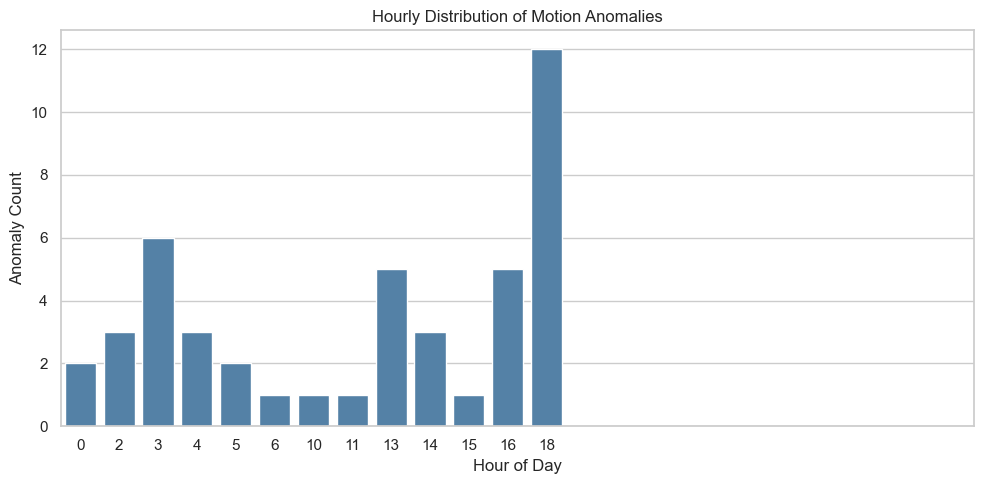

In [82]:
motion_anomalies['hour'] = motion_anomalies['start_ts'].dt.hour
hourly_anomalies = motion_anomalies.groupby('hour').size().reset_index(name='count')
plt.figure(figsize=(10, 5))
sns.barplot(x='hour', y='count', data=hourly_anomalies, color='steelblue', edgecolor='white')
plt.xlabel('Hour of Day')
plt.ylabel('Anomaly Count')
plt.title('Hourly Distribution of Motion Anomalies')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [83]:
# Save the motion anomalies to a CSV file
motion_anomalies.to_csv("motion_anomalies.csv", index=False)

<h3><center>Road Surface Sensors<h3>

In [84]:
road_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 258260 entries, 0 to 108475
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       258260 non-null  int64  
 1   ts                       258260 non-null  object 
 2   aplicom                  258260 non-null  object 
 3   lat                      258260 non-null  float64
 4   lon                      258260 non-null  float64
 5   hexdata                  258260 non-null  object 
 6   message_start            258260 non-null  object 
 7   sender_id                258260 non-null  int64  
 8   receiver_id              258260 non-null  int64  
 9   message_id               258260 non-null  int64  
 10  message_number           258260 non-null  int64  
 11  data_length              258260 non-null  int64  
 12  interface_version        258260 non-null  int64  
 13  error_code               258260 non-null  int64  
 14  data_anal

**en15518_surface_state**:European standard road state<br>
**surface_state**:Internal surface state code<br>
**water_layer_thickness**:Water depth on road<br>

In [85]:
road_df['ts'] = pd.to_datetime(road_df['ts'], format='ISO8601',errors='coerce')
road_df.head()

,id,ts,aplicom,lat,lon,hexdata,message_start,sender_id,receiver_id,message_id,...,surface_state,en15518_surface_state,grip,water_layer_thickness,ice_layer_thickness,snow_layer_thickness,unit_status_info,unit_error_bits,crc,geom
0,43509630,2025-11-10 01:50:38.942000+02:00,Aplicom A11 001,60.493152,22.288015,0xAB 0x1 0x0 0x20 0x3 0x36 0x0 0x44 0x0 0x90 0...,ab,1,0,20,...,3,3,0.697317,0.340409,0.0,0.0,9,8,8862,0101000020E6100000E8C1DD59BB4936407FFACF9A1F3F...
1,43509631,2025-11-10 01:50:38.945000+02:00,Aplicom A11 001,60.493152,22.288015,0xAB 0x1 0x0 0x20 0x4 0x36 0x0 0x44 0x0 0xA3 0...,ab,1,0,20,...,3,3,0.697985,0.337601,0.0,0.0,9,8,5d4b,0101000020E6100000E8C1DD59BB4936407FFACF9A1F3F...
2,43509632,2025-11-10 01:50:38.947000+02:00,Aplicom A11 001,60.493152,22.288015,0xAB 0x1 0x0 0x20 0x5 0x36 0x0 0x44 0x0 0xB7 0...,ab,1,0,20,...,3,3,0.695922,0.346411,0.0,0.0,9,8,c167,0101000020E6100000E8C1DD59BB4936407FFACF9A1F3F...
3,43509633,2025-11-10 01:50:38.949000+02:00,Aplicom A11 001,60.493152,22.288015,0xAB 0x1 0x0 0x20 0x6 0x36 0x0 0x44 0x0 0xCB 0...,ab,1,0,20,...,3,3,0.682641,0.413942,0.0,0.0,9,8,2af1,0101000020E6100000E8C1DD59BB4936407FFACF9A1F3F...
4,43509634,2025-11-10 01:50:38.950000+02:00,Aplicom A11 001,60.493152,22.288015,0xAB 0x1 0x0 0x20 0x7 0x36 0x0 0x44 0x0 0xDF 0...,ab,1,0,20,...,3,3,0.683389,0.409591,0.0,0.0,9,8,7647,0101000020E6100000E8C1DD59BB4936407FFACF9A1F3F...


In [86]:
road_df["en15518_surface_state"].value_counts()

en15518_surface_state
11    114649
3      74110
1      36091
2      28704
10      4706
Name: count, dtype: int64

In [87]:
road_df['aplicom'].unique()

array(['Aplicom A11 001'], dtype=object)

In [88]:
print(road_df['message_number'].describe().round(2))

count    258260.00
mean        127.55
std          73.86
min           0.00
25%          64.00
50%         128.00
75%         191.00
max         255.00
Name: message_number, dtype: float64


In [ ]:
# Grouping into measurement cycles, new cycle start when message_number reset.
road_df['new_cycle'] = road_df['message_number'].diff().fillna(1) < 0
road_df['cycle_id'] = road_df['new_cycle'].cumsum()

cycles = road_df.groupby('cycle_id').agg(message=('ts','size'), start=('ts','min'), end=('ts','max'))
cycles['duration_seconds'] = (cycles['end'] - cycles['start']).dt.total_seconds()
cycles['interval'] = cycles['start'].diff().dt.total_seconds()
print(cycles.describe().round(2))

# The MD30 sensor uses 128 seconds measurement cycle which is 2 min 8 s.
# Each cycle transmits a burst of messages. This is the Teconer MD30 protocol:
# it measures road conditions, then sends one large data burst per cycle.

# Total measurement cycles is 1031

       message  duration_seconds    interval
count  1031.00           1031.00     1030.00
mean    250.49           3678.36     5106.26
std      19.65         113461.05   121949.62
min      40.00              5.35        5.84
25%     252.00            127.52      128.01
50%     254.00            127.53      128.03
75%     254.00            127.56      128.04
max     296.00        3643259.75  3643261.02


In [90]:
# Finding the  missing data 
cycle_gaps = cycles[cycles['interval'] > 200]
cycle_gaps['missed_cycles'] = (cycle_gaps['interval']/128).round().astype(int) - 1
cycle_gaps['gap_min'] = (cycle_gaps['interval'] / 60).round(1)
cycle_gaps = cycle_gaps.reset_index()
print(f"Missing cycles:{len(cycle_gaps)}")
# For debugging, I used Qwen Max3

Missing cycles:14


C:\Users\Home\AppData\Local\Temp\ipykernel_39432\2442108962.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cycle_gaps['missed_cycles'] = (cycle_gaps['interval']/128).round().astype(int) - 1
C:\Users\Home\AppData\Local\Temp\ipykernel_39432\2442108962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cycle_gaps['gap_min'] = (cycle_gaps['interval'] / 60).round(1)


In [91]:
# Surface state mapping from Vaisala MD30 interface description
state = {1:"dry", 2:"moist", 3:"wet", 10:"streaming_water", 11:"slippery"}
road_df["surface_condition_name"]= road_df["en15518_surface_state"].replace(state).astype("category")

road_df.head()

,id,ts,aplicom,lat,lon,hexdata,message_start,sender_id,receiver_id,message_id,...,water_layer_thickness,ice_layer_thickness,snow_layer_thickness,unit_status_info,unit_error_bits,crc,geom,new_cycle,cycle_id,surface_condition_name
0,43509630,2025-11-10 01:50:38.942000+02:00,Aplicom A11 001,60.493152,22.288015,0xAB 0x1 0x0 0x20 0x3 0x36 0x0 0x44 0x0 0x90 0...,ab,1,0,20,...,0.340409,0.0,0.0,9,8,8862,0101000020E6100000E8C1DD59BB4936407FFACF9A1F3F...,False,0,wet
1,43509631,2025-11-10 01:50:38.945000+02:00,Aplicom A11 001,60.493152,22.288015,0xAB 0x1 0x0 0x20 0x4 0x36 0x0 0x44 0x0 0xA3 0...,ab,1,0,20,...,0.337601,0.0,0.0,9,8,5d4b,0101000020E6100000E8C1DD59BB4936407FFACF9A1F3F...,False,0,wet
2,43509632,2025-11-10 01:50:38.947000+02:00,Aplicom A11 001,60.493152,22.288015,0xAB 0x1 0x0 0x20 0x5 0x36 0x0 0x44 0x0 0xB7 0...,ab,1,0,20,...,0.346411,0.0,0.0,9,8,c167,0101000020E6100000E8C1DD59BB4936407FFACF9A1F3F...,False,0,wet
3,43509633,2025-11-10 01:50:38.949000+02:00,Aplicom A11 001,60.493152,22.288015,0xAB 0x1 0x0 0x20 0x6 0x36 0x0 0x44 0x0 0xCB 0...,ab,1,0,20,...,0.413942,0.0,0.0,9,8,2af1,0101000020E6100000E8C1DD59BB4936407FFACF9A1F3F...,False,0,wet
4,43509634,2025-11-10 01:50:38.950000+02:00,Aplicom A11 001,60.493152,22.288015,0xAB 0x1 0x0 0x20 0x7 0x36 0x0 0x44 0x0 0xDF 0...,ab,1,0,20,...,0.409591,0.0,0.0,9,8,7647,0101000020E6100000E8C1DD59BB4936407FFACF9A1F3F...,False,0,wet


In [92]:
road_df["surface_condition_name"].value_counts().head()

surface_condition_name
slippery           114649
wet                 74110
dry                 36091
moist               28704
streaming_water      4706
Name: count, dtype: int64

In [93]:
# I have 8 columns for road surface conditions, I am going to check the basic stats for each of them.

metrics_to_check = ["air_temperature", "relative_humidity", "surface_temperature", "grip",
                    "water_layer_thickness", "ice_layer_thickness","snow_layer_thickness",]

for metric_name in metrics_to_check:
    metric_values = road_df[metric_name].describe()
    print(f"{metric_name}:\n{metric_values}\n")


air_temperature:
count    258260.000000
mean          2.963334
std           9.321583
min         -12.620000
25%          -6.860000
50%           8.090000
75%          11.290000
max          18.190001
Name: air_temperature, dtype: float64

relative_humidity:
count    258260.000000
mean         68.381145
std          16.772314
min          33.639999
25%          54.970001
50%          67.779999
75%          79.110001
max         100.000000
Name: relative_humidity, dtype: float64

surface_temperature:
count    258260.000000
mean          3.397858
std           9.375059
min         -12.790009
25%          -6.549988
50%           8.329987
75%          11.510010
max          18.589996
Name: surface_temperature, dtype: float64

grip:
count    258260.000000
mean          0.458195
std           0.305384
min           0.100000
25%           0.111460
50%           0.589202
75%           0.747730
max           0.820000
Name: grip, dtype: float64

water_layer_thickness:
count    258260.000000
mean

In [94]:
# grip is the sensor friction estimate for the road surface.
# higher grip = more available traction, lower grip = more slippery, the is range 0.10 - 0.82.
# Water, ice, snow thickness are in mm
# 0.10–0.82 matches the documented grip range
# water layer thickness max is 34.55 mm. 


# https://www.vaisala.com/sites/default/files/documents/MD30-Interface-Description-in-English-M212201EN.pdf

In [ ]:
# Median of key metrics per surface condition
columns = ["air_temperature", "surface_temperature", "grip",'ater_layer_thickness',
            "ice_layer_thickness",  'snow_layer_thickness', "relative_humidity"]

summary = road_df.groupby("surface_condition_name")[columns].median().round(3)
summary.index.name = "condition"
print(summary)

                 air_temperature  surface_temperature   grip  \
condition                                                      
dry                        11.30                11.67  0.820   
moist                      11.55                11.55  0.797   
slippery                   -7.31                -7.01  0.109   
streaming_water             6.50                 8.13  0.362   
wet                        10.84                10.99  0.671   

                 water_layer_thickness  ice_layer_thickness  \
condition                                                     
dry                              0.000                0.000   
moist                            0.103                0.000   
slippery                         0.000                0.382   
streaming_water                  2.574                0.000   
wet                              0.494                0.000   

                 snow_layer_thickness  relative_humidity  
condition                                         

C:\Users\Home\AppData\Local\Temp\ipykernel_39432\2359391789.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = road_df.groupby("surface_condition_name")[columns].median().round(3)


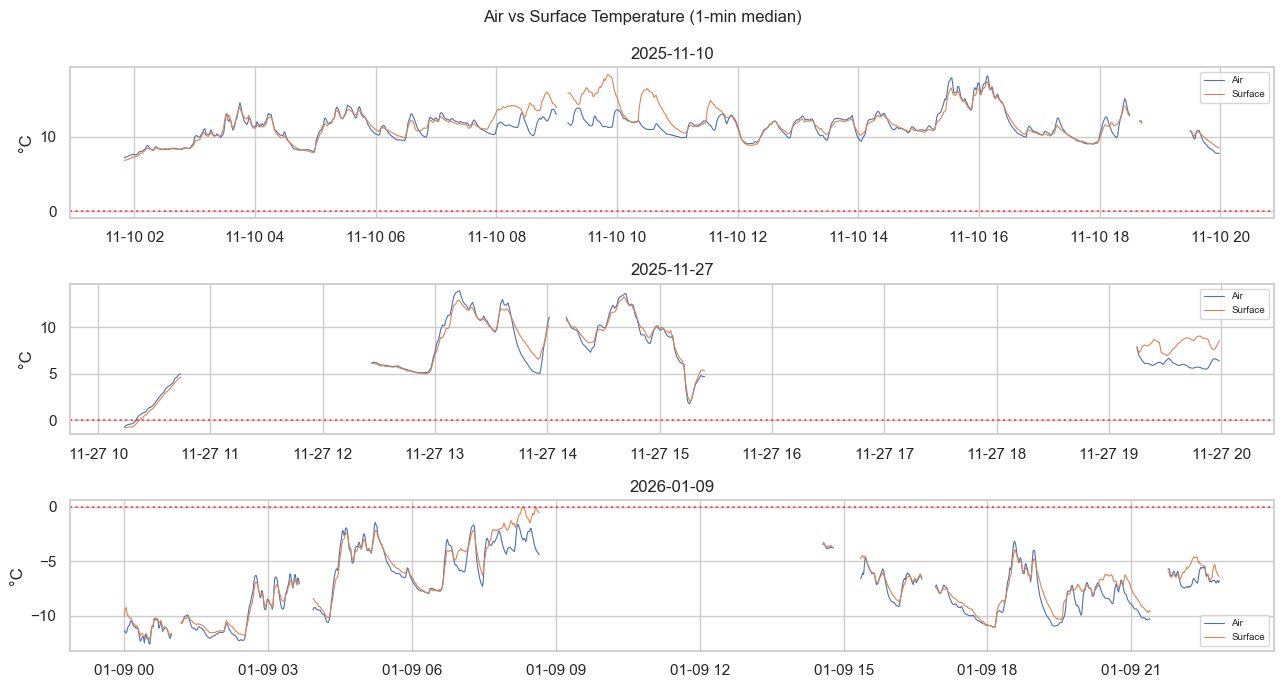

In [ ]:
# When surface temperature drops below 0 c while air is still positive 
road = road_df.copy()
road["ts"] = pd.to_datetime(road["ts"])
road["date"] = road["ts"].dt.date
dates = sorted(road["date"].unique())
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=False)
for i, d in enumerate(dates):
    ax = axes[i]
    day = road[road["date"] == d].set_index("ts").resample("1min").median(numeric_only=True)
    ax.plot(day.index, day["air_temperature"], label="Air", lw=0.8)
    ax.plot(day.index, day['surface_temperature'], 
    
    label="Surface", lw=0.8)
    ax.axhline(0, color="red", ls=":", alpha=0.6)
    ax.set_ylabel("°C"); ax.set_title(str(d)); ax.legend(fontsize=7)
fig.suptitle("Air vs Surface Temperature (1-min median)", fontsize=12)
plt.tight_layout()
plt.show()

# Nov 10: 7-18 C, Nov 27: 2-15 C ,late autumn  with some gaps, Jan 9: entirely below 0 C, -12 to -2C . Surface temperature closely tracks air temperature.
#  Now let me look at grip with ice layer timelin

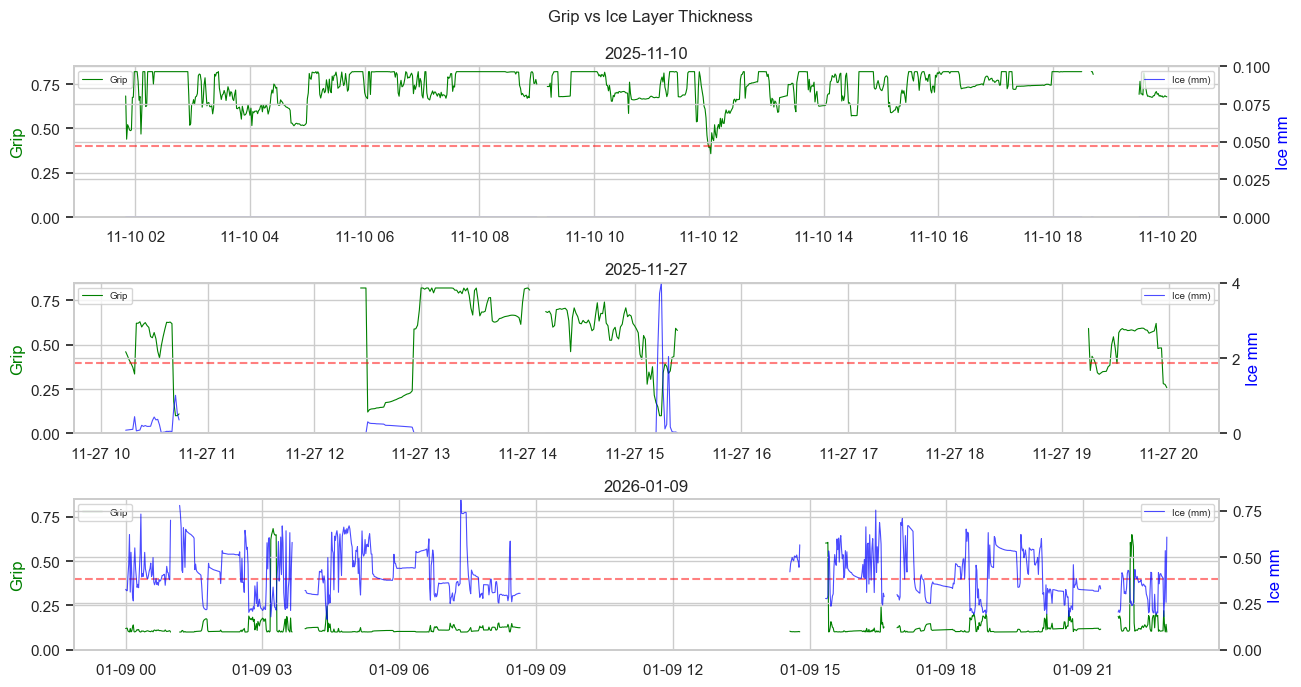

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=False)
for i, d in enumerate(dates):
    ax = axes[i]; ax2 = ax.twinx()
    day = road[road["date"] == d].set_index("ts").resample("1min").median(numeric_only=True)

    ax.plot(day.index, day["grip"], color="green", lw=0.8, label="Grip")
    ax2.plot(day.index, day["ice_layer_thickness"], color="blue", lw=0.8, alpha=0.7, label="Ice (mm)")
    ax.axhline(0.4, color="red", ls="--", alpha=0.5)
    
    ax.set_ylabel("Grip", color="green"); ax2.set_ylabel("Ice mm", color="blue")
    ax.set_title(str(d)); ax.set_ylim(0, 0.85); ax2.set_ylim(0, max(day["ice_layer_thickness"].max(), 0.1))
    ax.legend(loc="upper left", fontsize=7)
    ax2.legend(loc="upper right", fontsize=7)

fig.suptitle("Grip vs Ice Layer Thickness", fontsize=12)
plt.tight_layout(); plt.show()

# Nov 10: no ice, grip stays high.
# Nov 27: ice spike at 10:00 to 10:30 with grip crash to 0.05 , the truck was at the sensor station during cold morning.
# Jan 9: ice  is around 0.3 to 0.7mm

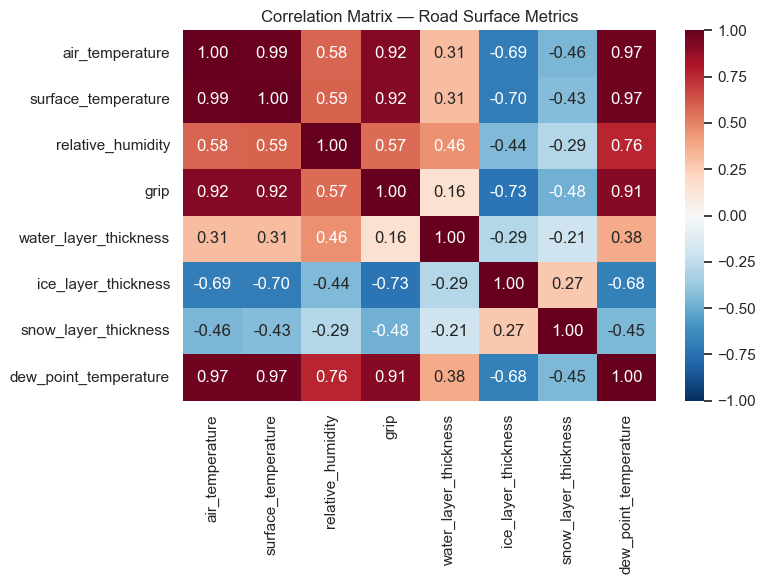

In [ ]:
correlation_columns = ["air_temperature", "surface_temperature", "relative_humidity",
                     "grip", "water_layer_thickness", "ice_layer_thickness", 
                      "snow_layer_thickness", 'dew_point_temperature']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(road[correlation_columns].corr().round(2), annot=True, cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, fmt=".2f")

plt.tight_layout()
plt.show()
# air_temp surface_temp:
# grip and  ice: strong negative, ice kills grip
# ice and temperature: ice forms when cold
# dew_point aad temp: are redundant

<h2><center>Merging road surface ds with Motion Anomalies<h2>

In [ ]:
merged_road_motion = pd.merge_asof( motion_anomalies, road_df[["ts", "grip", "surface_temperature","ice_layer_thickness",
                                                               "water_layer_thickness", "snow_layer_thickness", 
                                                               "surface_condition_name","air_temperature", 'relative_humidity']],
                                 left_on="start_ts", right_on="ts", tolerance=pd.Timedelta("30s"), direction="nearest")

merged_road_motion["time_diff_s"]= (merged_road_motion["start_ts"]-merged_road_motion["ts"]).dt.total_seconds().abs()
matched = merged_road_motion["ts"].notna().sum()

print(f"Matched: {matched}/{len(motion_anomalies)} ({matched/len(motion_anomalies)*100:.0f}%)")

Matched: 39/45 (87%)


In [100]:
merged_road_motion["surface_condition_name"].value_counts()

surface_condition_name
wet                15
dry                12
slippery            7
moist               5
streaming_water     0
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_39432\3569432688.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cond, grp in merged_road_motion.groupby("surface_condition_name"):


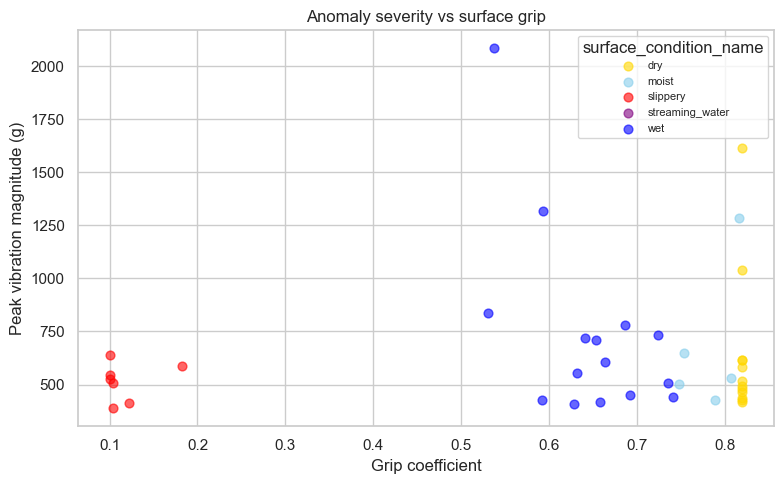

In [101]:
# peak vibration magnitude vs grip
colors = {"dry": "gold", "moist": "skyblue", "wet": "blue", "streaming_water": "purple", "slippery": "red"}
fig, ax = plt.subplots(figsize=(8, 5))
for cond, grp in merged_road_motion.groupby("surface_condition_name"):
    ax.scatter(grp["grip"], grp["peak_mag"], label=cond, c=colors.get(cond, "gray"), alpha=0.6, s=40)
ax.set_xlabel("Grip coefficient")
ax.set_ylabel("Peak vibration magnitude (g)")
ax.set_title("Anomaly severity vs surface grip")
ax.legend(title="surface_condition_name", fontsize=8)
plt.tight_layout()
plt.show()

# slippery cluster at grip smaller 0.2, 
# wet, dry, moist clusters are bigger than 0.5 with higher peak magnitudes.
# The strongest vibrations bigger 1000g  happens during wet conditions at good grip

In [102]:
merged_road_motion.groupby("surface_condition_name")["peak_mag"].median().round(0)

C:\Users\Home\AppData\Local\Temp\ipykernel_39432\3854344451.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_road_motion.groupby("surface_condition_name")["peak_mag"].median().round(0)


surface_condition_name
dry                506.0
moist              533.0
slippery           528.0
streaming_water      NaN
wet                604.0
Name: peak_mag, dtype: float64

<h2><center>Flic Button Press Sessions with Motion Sensors Analysis<h2>

In [103]:
press_events.columns

Index(['address', 'Press_number', 'start', 'end', 'packet_count', 'lat', 'lon',
       'rssi_median', 'duration_s', 'hour', 'period', 'road', 'town',
       'is_dark'],
      dtype='object')

In [104]:
motion_df.columns

Index(['id', 'ts', 'aplicom', 'companyid', 'address', 'rssi', 'advdata', 'lat',
       'lon', 'geom', 'temperature', 'accx', 'accy', 'accz', 'battvoltage',
       'txpower', 'movcounter', 'measseqnum', 'calibrated_accx',
       'calibrated_accy', 'calibrated_accz'],
      dtype='object')

In [105]:
road_df.columns

Index(['id', 'ts', 'aplicom', 'lat', 'lon', 'hexdata', 'message_start',
       'sender_id', 'receiver_id', 'message_id', 'message_number',
       'data_length', 'interface_version', 'error_code', 'data_analyze_count',
       'data_status_warning', 'data_status_error', 'air_temperature',
       'relative_humidity', 'dew_point_temperature', 'frost_point_temperature',
       'surface_temperature', 'surface_state', 'en15518_surface_state', 'grip',
       'water_layer_thickness', 'ice_layer_thickness', 'snow_layer_thickness',
       'unit_status_info', 'unit_error_bits', 'crc', 'geom', 'new_cycle',
       'cycle_id', 'surface_condition_name'],
      dtype='object')

In [ ]:
# assigning motion ds to press session: before, during,  after
# For each press session, let's find motion packets in windows: 60 seconds before, during, 60 seconds afte

window_time = 60  
rows = []
for _, press in press_events.iterrows():
    # defining  the start of the matching window
    before_start = press["start"] - pd.Timedelta(seconds=window_time)
    # defining the end of the matching window
    after_end = press["end"] + pd.Timedelta(seconds=window_time)
    #  extractting matching motion rows
    chunk = motion_df[(motion_df['ts'] >= before_start)&(motion_df['ts'] <=after_end)].copy()
    chunk['Press_number'] = press["Press_number"]
    # labeling each motion row as before, during, after
    chunk['phase'] = np.where(chunk['ts'] < press['start'], 'before', np.where(chunk['ts'] <= press['end'], "during", 'after'))
    rows.append(chunk)
# Mergeing all chunks together
merged = pd.concat(rows, ignore_index=True)
print(f"Matched motion packets: {len(merged):,}/{len(motion_df):,}")

Matched motion packets: 127/26,276


In [ ]:
# I am going to build one summary for each press session
# ALready I merged the motion ds with press session.

# calculating the magnitude
merged['magnitude']=np.sqrt(merged['calibrated_accx']**2+merged["calibrated_accy"]**2+merged['calibrated_accz']**2)

# Finding the peak motion row per press session
peak_idx= merged.groupby('Press_number')['magnitude'].idxmax()
peak_view=(merged.loc[peak_idx,['Press_number', 'phase', "magnitude"]].rename(columns={'phase': 'peak_phase','magnitude': 'peak_magnitude'}))

road_rows = []
for _, flic_sesion in press_events[["Press_number", 'start', 'end']].iterrows():
    t0 = flic_sesion["start"]- pd.Timedelta(seconds=window_time)
    t1 = flic_sesion['end']+ pd.Timedelta(seconds=window_time)

    road_data = road_df[(road_df['ts'] >= t0) & (road_df['ts'] <= t1)].sort_values('ts')
    row = {'Press_number': flic_sesion['Press_number'],"speed_at_press_kmh":np.nan,'grip': np.nan,'surface_condition_name': np.nan}

    if len(road_data):
        road_data['dt_press_s'] = (road_data['ts']-flic_sesion['start']).dt.total_seconds().abs()
        near_row = road_data.loc[road_data['dt_press_s'].idxmin()]
        row['grip'] = round(near_row['grip'], 3) if pd.notna(near_row['grip']) else np.nan
        row['surface_condition_name'] = near_row['surface_condition_name']

    if len(road_data)>=2:
        road_data["dt_s"]=road_data['ts'].diff().dt.total_seconds()
        road_data["distance_meter"] = haversine(road_data['lat'].shift(), road_data['lon'].shift(),road_data['lat'], road_data['lon'])
        road_data['speed_kmh'] = (road_data["distance_meter"]/road_data['dt_s']) * 3.6
        speed_rows = road_data.loc[road_data['speed_kmh'].notna()]

        if len(speed_rows): row['speed_at_press_kmh']=round(speed_rows.loc[speed_rows['dt_press_s'].idxmin(), 'speed_kmh'], 1)

    road_rows.append(row)

road_phase = pd.DataFrame(road_rows)

danger_analyzed = (press_events[['Press_number', 'start', 'is_dark', 'road', 'town']].merge(peak_view, on="Press_number", how='left')
                                .merge(road_phase, on="Press_number", how='left').sort_values('Press_number').reset_index(drop=True))
danger_analyzed

# For debugging, I used Qwen Max3. 

,Press_number,start,is_dark,road,town,peak_phase,peak_magnitude,speed_at_press_kmh,grip,surface_condition_name
0,1,2025-11-10 01:50:40.220000+02:00,True,Telekatu,Turku,during,44.795129,0.0,0.688,wet
1,2,2025-11-10 04:06:25.747000+02:00,True,Meriniitynkatu,Salon suuralue,during,2082.971129,37.8,0.623,wet
2,3,2025-11-10 04:28:52.086000+02:00,True,Haarlantie,Salo,before,634.608557,13.8,0.746,wet
3,4,2025-11-10 05:40:50.774000+02:00,True,Ekerövägen,Raseborg,after,225.338707,12.5,0.677,wet
4,5,2025-11-10 09:54:27.850000+02:00,False,Town Centre,Hanko,NaN,NaN,0.4,0.820,dry
5,6,2025-11-10 18:05:23.268000+02:00,True,Otsonkatu,Salon suuralue,after,108.827772,20.2,0.820,dry
6,7,2025-11-10 18:06:24.294000+02:00,True,Ahmankatu,Salon suuralue,after,108.827772,0.0,0.820,dry
7,8,2025-11-27 00:06:20.323000+02:00,True,Kiskontie,Salo,during,324.589015,NaN,NaN,NaN
8,9,2025-11-27 00:11:01.214000+02:00,True,Kiskontie,Salo,after,352.733285,NaN,NaN,NaN
9,10,2025-11-27 13:06:14.171000+02:00,False,Nesteentie,Raisio,during,60.739139,52.2,0.820,dry


In [108]:
# My analysis for each press based on motion and road data:
# Press 1: 
# that is happened in dark and in Telekatu, Turku, the truck was completely stopped when the driver pressed. The magnitude is too low. 
# I guess that the driver  pressed the button when he might see the danger, while the truck was stopped.
#--------------------------------------------


# Press 2: 
# that is happened in dark and in , Salon suuralue.
# This is the strongest one, the driver was moving at 37.8 km/h on a wet road at night. The motion peaked during the press
# That was serious shake.
# --------------------------------------------


# Press 3:
# that is happened is dark and in wet Haarlantie road, Salo
# Magnitude is 634.6 and the grip is 0.74. 
# the driver pressed the button after the shake, wet road at night in Salo, same stretch as Press 2 which happened 22 minutes earlier on the same road.
# --------------------------------------------


# Press 4:
#  that is happened in dark and in wet  Ekerövägen road, Raseborg, The not strong shake.
# ---------------------------------------------

# Press 5:
#  that is happened in daytime and in dry in Town Centre, Hanko.   
# No motion data at all and the speed is low, the driver might  press accidentally or might see the danger
# ---------------------------------------------

# Press 6 and 7: Both have same values, I will combine them together as one press session.
# That is happened in Night and dry  in Otsonkatu / Ahmankatu, Salon suuralue
# the speed is 20 and magnitude is 108, dry road with good grip means this was not  traction hazard.
# ----------------------------------------------

# Press 8 and 9: Same problem as 6 and 7, I will combine them together as one press session.
# That is happened in dark  in Kissankatu, Salo
# There is no motion data and road data.
# ----------------------------------------------



# Press 10, 11 and 12: same problem.
# All of them happened in daytime and in dry in same address: Nesteentie, Raisio
# These three presses happened in 110 second range.
# But 12 and 11 have exactly same values, I will combine them together as one press session.
# press 10 is pressed when the speed is 52.2 ande magnitude 60 which is not strong
# press 11 is pressed when the speed is too low, but ffor press 12, the speed is 38 
# For all of them the road is dry with good grip. 
# ----------------------------------------------

# Press 13: 
# that is happened in daytime in Turku-Helsinki moottoritie, Salo 
# there is no road data, the magnitude is 209 which is not strong. 
# ----------------------------------------------

# Press 14 and 15: same problem, I will combine them together as one press session.
# that is happened daytime in  Kiskontie, Salo
# the raod was wet and the grip was 0.67, speed was 75
# But press 16 happened in same road one minute and the speed is almost same.
# -----------------------------------------------

# Press 16:
# that is exactly same as press 14 and 15, but the grip and the road condition is different.
# speed is 79 and the nmagnitude is 109 which is not strong, the road was streaming water with low grip.
# this make sense because high speed on streaming water is dangerous for truck.
# -----------------------------------------------

# Press 17: that is happened in daytime and in streaming water with low grip in Mustiontie, Lohja
# the speed is 64, there is no motion data, for 14, 15 and 16, the speed is high. 
# -----------------------------------------------


# Press 18: 
# that is happened in night and slippery road in Nesteentie, Raisio  with low grip.
# the speed is 12 and magnitude is 247 which kind of strong, but the speed is low.

# -----------------------------------------------
# Press 19:
# that is happened in night and slippery road in  Valtatie, Paimio with low grip.
# the speed is 18, there is no motion data. 
# -----------------------------------------------


# Press 20:
# that is happened in night in Joensuunkatu, Salon suuralue. There is not more data
# -----------------------------------------------

# Press 21:
# that is happened in night and in Joensuunkatu, Salon suuralue
# the magnitude is 108 which is not strong. There is no more data.
# -----------------------------------------------

# Press 22:
# that is happened in daytime and in slippery road  Valtatie, Halikko with low grip.
# the speed is 77 which is high, but there is no motion data.
# -----------------------------------------------

# Press 23 and 24: same problem, I will combine them together as one press session.
# that is happened in daytime and in slippery road  Valtatie -Iso-Iivarintie, Paimio with low grip.
# the speed is 40 and magnitude 152 
# ------------------------------------------------

# Press 25:
# that is happened in night and in slippery road  in  Järvenkyläntie, Salo with low grip.
# the speed is 13, there is no motion data. the driver drove slowly on slippery road during night. 


# mmm, Interesting, on 10th of November, 1 until 4 press happened in in continuously driving:
# 01:50, 4:06, 4:28 and 5:40
# the route started from turku, then drove to Salo and then drove to Raseborg. 
# This is 4 hours of night driving on wet roads in November and in darkness, wet road

# 27 th of November is also continuous driving, 10 until 17 presses.
# The deriver drove from Raisio to Salo and then drove to Lohja. 
# The road condition is  getting worse as the journey progresses, from dry to wet and then to streaming water. 
# In less than 2 hours and 6 minutes, the road grip dropped from 0.820 to 0.256. 

# Kiskontie road in Salo happened 5 presses during night and afternoon. 
# In January slippery conditions caused most later presses
